#  Preprocessing Data Indeks Desa Membangun (IDM) 2024
## Kelompok 3 - Tugas Besar Data Analytics (II4013)

**Dataset:** Indeks Desa Membangun (IDM) Tahun 2024 - Hasil Pemutakhiran  
**Sumber:** Kementerian Desa, PDT, dan Transmigrasi (Kemendesa PDTT)  
**Cakupan:** ~74.961 desa di seluruh Indonesia  
**Kerangka:** OSEMN - Tahap **S**crub (Preprocessing)

---

### Alur Notebook

| # | Langkah | Metode |
|---|---------|--------|
| 0 | Load dataset dari Google Drive | `gdown` / mount Drive |
| 1 | Inspeksi awal | `.info()`, `.describe()`, missing value map |
| 2 | Data cleaning | Drop kolom junk, hapus duplikat, tangani NaN |
| 3 | Validasi tipe data | `pd.to_numeric`, ordinal encoding STATUS_IDM |
| 4 | Deteksi & penanganan outlier | Metode IQR + Winsorization (capping) |
| 5 | Ekstraksi statistik per provinsi | Median (numerik), Modus (kategorik) |
| 6 | Persiapan fitur clustering | `StandardScaler` pada IKL, IKE, IKS |
| 7 | K optimal | Elbow (WCSS) + Silhouette Score |
| 8 | K-Means Clustering | Scatter 2D (IKL×IKE) & 3D, profil klaster |
| 9 | Simpan hasil | `.csv` siap pakai |

---

### Variabel Dataset

| Kolom | Tipe | Keterangan |
|-------|------|------------|
| `KODE_PROV`, `NAMA_PROVINSI` | str | Identitas provinsi |
| `KODE_KAB`, `NAMA_KABUPATEN` | str | Identitas kabupaten |
| `KODE_KEC`, `NAMA_KECAMATAN` | str | Identitas kecamatan |
| `KODE_DESA`, `NAMA_DESA` | str | Identitas desa |
| **`IKS_2024`** | float [0-1] | Indeks Ketahanan Sosial |
| **`IKE_2024`** | float [0-1] | Indeks Ketahanan Ekonomi |
| **`IKL_2024`** | float [0-1] | Indeks Ketahanan Lingkungan |
| **`NILAI_IDM_2024`** | float [0-1] | Komposit IDM = rata-rata IKS+IKE+IKL |
| **`STATUS_IDM_2024`** | str | Kategori: Sangat Tertinggal s.d. Mandiri |


In [ ]:
# Instalasi dependensi (jalankan sekali di Google Colab)
%%capture
!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl gdown
print('Instalasi selesai.')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi tampilan
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (10, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans'
})
sns.set_theme(style='whitegrid', palette='muted')

print('[OK] Semua library berhasil diimpor.')

[OK] Semua library berhasil diimpor.


---
## 0. Load Dataset dari Google Drive

Tersedia dua cara untuk memuat dataset di Google Colab. Pilih salah satu dengan mengatur variabel `METODE`.

### Cara A - `gdown` (via File ID Google Drive)
1. Upload `indeks-desa-membangun-tahun-2024-hasil-pemutakhiran.xlsx` ke Google Drive
2. Klik kanan file → **Dapatkan link** → ubah akses ke *Anyone with the link*
3. Salin **File ID** dari URL: `https://drive.google.com/file/d/`**`FILE_ID_INI`**`/view`
4. Tempel di variabel `FILE_ID` pada sel berikutnya

### Cara B - Mount Google Drive (path langsung)
1. Jalankan sel, lalu izinkan akses Drive saat muncul dialog
2. Sesuaikan `DRIVE_PATH` sesuai lokasi file di Drive Anda


In [ ]:
# ================================================================
#  KONFIGURASI - Sesuaikan sebelum menjalankan
# ================================================================
METODE = 'B'          # Pilih 'A' (gdown) atau 'B' (mount drive)

# -- Cara A: gdown via File ID --
FILE_ID = 'MASUKKAN_FILE_ID_GOOGLE_DRIVE_ANDA'

# -- Cara B: path di Google Drive yang sudah di-mount --
# Ganti 'DataAnalytics' sesuai nama folder Anda di My Drive
DRIVE_PATH = '/content/drive/MyDrive/Tubes Data Analytics/indeks-desa-membangun-tahun-2024-hasil-pemutakhiran.xlsx'
# ================================================================

if METODE == 'A':
    import gdown
    url = f'https://drive.google.com/uc?id={FILE_ID}'
    output_path = 'idm_2024.xlsx'
    print('Mengunduh file dari Google Drive...')
    gdown.download(url, output_path, quiet=False)
    df_raw = pd.read_excel(output_path, engine='openpyxl')
    print(f'\n[OK] File berhasil diunduh dan dimuat dari Drive (gdown).')

elif METODE == 'B':
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    df_raw = pd.read_excel(DRIVE_PATH, engine='openpyxl')
    print(f'\n[OK] File berhasil dimuat dari: {DRIVE_PATH}')

else:
    raise ValueError("METODE harus 'A' atau 'B'.")

print(f'Ukuran dataset: {df_raw.shape[0]:,} baris x {df_raw.shape[1]} kolom')
df_raw.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

[OK] File berhasil dimuat dari: /content/drive/MyDrive/Tubes Data Analytics/indeks-desa-membangun-tahun-2024-hasil-pemutakhiran.xlsx
Ukuran dataset: 75,265 baris x 15 kolom


,KODE_PROV,NAMA_PROVINSI,KODE_KAB,NAMA_KABUPATEN,KODE_KEC,NAMA_KECAMATAN,KODE_DESA,NAMA_DESA,IKS_2024,IKE_2024,IKL_2024,NILAI_IDM_2024,STATUS_IDM_2024,Keterangan,Unnamed: 14
0,11,ACEH,1101,ACEH SELATAN,110101,BAKONGAN,1101012001,KEUDE BAKONGAN,0.8000,0.9000,0.5333,0.7444,MAJU,NaN,NaN
1,11,ACEH,1101,ACEH SELATAN,110101,BAKONGAN,1101012002,UJONG MANGKI,0.6629,0.6333,0.5333,0.6098,BERKEMBANG,NaN,NaN
2,11,ACEH,1101,ACEH SELATAN,110101,BAKONGAN,1101012003,NaN,0.7029,0.6167,0.5333,0.6176,BERKEMBANG,NaN,NaN


---
## 1. Inspeksi Awal Data


In [ ]:
print('=' * 55)
print('INFORMASI DATASET')
print('=' * 55)
print(f'Jumlah baris  : {df_raw.shape[0]:,}')
print(f'Jumlah kolom  : {df_raw.shape[1]}')
print()
df_raw.info()
print()
df_raw.describe(include='all')

INFORMASI DATASET
Jumlah baris  : 75,265
Jumlah kolom  : 15

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75265 entries, 0 to 75264
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   KODE_PROV        75265 non-null  int64  
 1   NAMA_PROVINSI    75265 non-null  object 
 2   KODE_KAB         75265 non-null  int64  
 3   NAMA_KABUPATEN   75265 non-null  object 
 4   KODE_KEC         75265 non-null  int64  
 5   NAMA_KECAMATAN   75265 non-null  object 
 6   KODE_DESA        75265 non-null  int64  
 7   NAMA_DESA        75264 non-null  object 
 8   IKS_2024         75265 non-null  object 
 9   IKE_2024         75261 non-null  float64
 10  IKL_2024         75261 non-null  float64
 11  NILAI_IDM_2024   75261 non-null  float64
 12  STATUS_IDM_2024  75261 non-null  object 
 13  Keterangan       5118 non-null   object 
 14  Unnamed: 14      1 non-null      object 
dtypes: float64(3), int64(4), object(8)
memory u

,KODE_PROV,NAMA_PROVINSI,KODE_KAB,NAMA_KABUPATEN,KODE_KEC,NAMA_KECAMATAN,KODE_DESA,NAMA_DESA,IKS_2024,IKE_2024,IKL_2024,NILAI_IDM_2024,STATUS_IDM_2024,Keterangan,Unnamed: 14
count,75265.0000,75265,75265.0000,75265,75265.0000,75265,75265.0000,75264,75265.0000,75261.0000,75261.0000,75261.0000,75261,5118,1
unique,NaN,37,NaN,434,NaN,6247,NaN,57915,174.0000,NaN,NaN,NaN,5,2,1
top,NaN,JAWA TENGAH,NaN,ACEH UTARA,NaN,ABENAHO,NaN,SIDOMULYO,0.8171,NaN,NaN,NaN,BERKEMBANG,Update 2023,s
freq,NaN,7810,NaN,852,NaN,108,NaN,91,1888.0000,NaN,NaN,NaN,24532,4011,1
mean,42.9885,NaN,4308.1429,NaN,430824.6381,NaN,4308248391.1803,NaN,NaN,0.6198,0.7502,0.7120,NaN,NaN,NaN
std,26.9972,NaN,2697.9290,NaN,269793.2179,NaN,2697932178.2179,NaN,NaN,0.1736,0.1462,0.1208,NaN,NaN,NaN
min,11.0000,NaN,1101.0000,NaN,110101.0000,NaN,1101012001.0000,NaN,NaN,0.1139,0.0000,0.2176,NaN,NaN,NaN
25%,17.0000,NaN,1701.0000,NaN,170101.0000,NaN,1701012005.0000,NaN,NaN,0.5167,0.6667,0.6448,NaN,NaN,NaN
50%,35.0000,NaN,3505.0000,NaN,350507.0000,NaN,3505072005.0000,NaN,NaN,0.6333,0.6667,0.7156,NaN,NaN,NaN
75%,64.0000,NaN,6408.0000,NaN,640804.0000,NaN,6408042011.0000,NaN,NaN,0.7333,0.8667,0.8075,NaN,NaN,NaN


Kolom dengan Missing Values:


,Jumlah NaN,Persentase (%)
Unnamed: 14,75264,100.0000
Keterangan,70147,93.2000
IKE_2024,4,0.0100
STATUS_IDM_2024,4,0.0100
IKL_2024,4,0.0100
NILAI_IDM_2024,4,0.0100
NAMA_DESA,1,0.0000


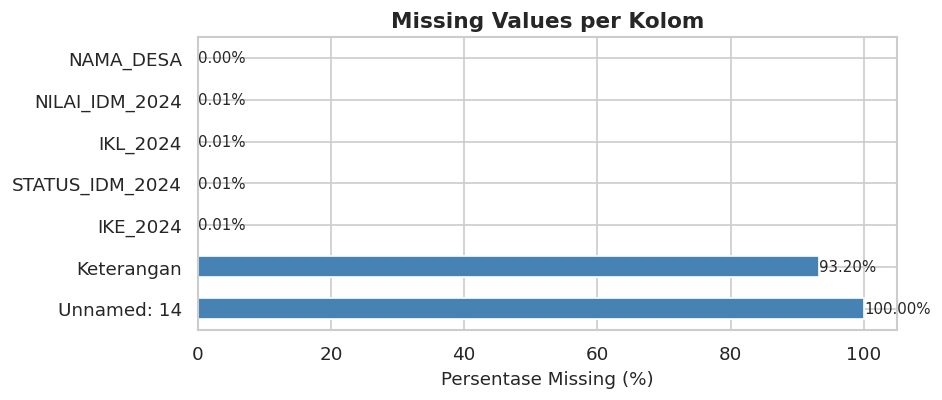

In [ ]:
# Ringkasan missing values
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({
    'Jumlah NaN': missing,
    'Persentase (%)': missing_pct
}).query('`Jumlah NaN` > 0').sort_values('Jumlah NaN', ascending=False)

if missing_df.empty:
    print('[OK] Tidak ada missing values pada dataset.')
else:
    print('Kolom dengan Missing Values:')
    display(missing_df)

    # Visualisasi
    fig, ax = plt.subplots(figsize=(8, max(3, len(missing_df) * 0.5)))
    missing_df['Persentase (%)'].plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_xlabel('Persentase Missing (%)', fontsize=11)
    ax.set_title('Missing Values per Kolom', fontsize=13, fontweight='bold')
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.2f}%', (p.get_width() + 0.05, p.get_y() + p.get_height() / 2),
                    va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('missing_values.png', bbox_inches='tight')
    plt.show()

---
## 2. Data Cleaning

### 2.1 Drop Kolom Tidak Relevan

Kolom `Keterangan` dan `Unnamed: 14` tidak mengandung informasi bermakna dan perlu dihapus sebelum analisis.


In [ ]:
# Salin ke working dataframe
df = df_raw.copy()

# Deteksi kolom junk (by exact name atau prefix 'Unnamed')
cols_to_drop = [c for c in df.columns
                if c in ['Keterangan', 'Unnamed: 14']
                or c.startswith('Unnamed:')]

if cols_to_drop:
    df.drop(columns=cols_to_drop, inplace=True)
    print(f'[OK] Kolom dihapus: {cols_to_drop}')
else:
    print('Tidak ditemukan kolom tidak relevan.')

print(f'Kolom tersisa ({df.shape[1]}): {list(df.columns)}')

[OK] Kolom dihapus: ['Keterangan', 'Unnamed: 14']
Kolom tersisa (13): ['KODE_PROV', 'NAMA_PROVINSI', 'KODE_KAB', 'NAMA_KABUPATEN', 'KODE_KEC', 'NAMA_KECAMATAN', 'KODE_DESA', 'NAMA_DESA', 'IKS_2024', 'IKE_2024', 'IKL_2024', 'NILAI_IDM_2024', 'STATUS_IDM_2024']


### 2.2 Pengecekan dan Penghapusan Duplikat


In [ ]:
n_duplikat = df.duplicated().sum()
print(f'Jumlah baris duplikat ditemukan: {n_duplikat:,}')

if n_duplikat > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'[OK] Duplikat dihapus. Sisa baris: {len(df):,}')
else:
    print('[OK] Tidak ada duplikat.')

Jumlah baris duplikat ditemukan: 0
[OK] Tidak ada duplikat.


### 2.3 Penanganan Missing Values

| Kolom | Strategi | Alasan |
|-------|----------|--------|
| `NAMA_DESA` | Isi `'Tidak Diketahui'` | Nama desa tidak memengaruhi analisis numerik |
| `IKS_2024`, `IKE_2024`, `IKL_2024`, `NILAI_IDM_2024` | Isi dengan **median** kolom | Median robust terhadap distribusi skewed |
| Baris di mana **semua 4 indeks** sekaligus NaN | **Hapus baris** | Tidak ada informasi yang bisa direkonstruksi |


In [ ]:
KOLOM_INDEKS = ['IKS_2024', 'IKE_2024', 'IKL_2024', 'NILAI_IDM_2024']

# Hapus baris di mana semua 4 kolom indeks sekaligus NaN
mask_semua_nan = df[KOLOM_INDEKS].isnull().all(axis=1)
n_hapus = mask_semua_nan.sum()
if n_hapus > 0:
    df = df[~mask_semua_nan].reset_index(drop=True)
    print(f'[!]  Baris dengan semua indeks kosong dihapus: {n_hapus}')

# Isi NAMA_DESA yang kosong
if 'NAMA_DESA' in df.columns:
    n_desa_nan = df['NAMA_DESA'].isnull().sum()
    df['NAMA_DESA'] = df['NAMA_DESA'].fillna('Tidak Diketahui')
    if n_desa_nan > 0:
        print(f'[OK] NAMA_DESA: {n_desa_nan} nilai kosong diisi dengan "Tidak Diketahui"')

# Isi kolom indeks dengan median masing-masing
for col in KOLOM_INDEKS:
    if col in df.columns:
        n_nan = df[col].isnull().sum()
        if n_nan > 0:
            med = df[col].median()
            df[col] = df[col].fillna(med)
            print(f'[OK] {col}: {n_nan} nilai kosong diisi median = {med:.4f}')

print(f'\nTotal NaN tersisa: {df.isnull().sum().sum()}')
print(f'Ukuran dataset setelah cleaning: {df.shape[0]:,} baris x {df.shape[1]} kolom')

[OK] NAMA_DESA: 1 nilai kosong diisi dengan "Tidak Diketahui"
[OK] IKE_2024: 4 nilai kosong diisi median = 0.6333
[OK] IKL_2024: 4 nilai kosong diisi median = 0.6667
[OK] NILAI_IDM_2024: 4 nilai kosong diisi median = 0.7156

Total NaN tersisa: 4
Ukuran dataset setelah cleaning: 75,265 baris x 13 kolom


---
## 3. Validasi Tipe Data

Pastikan kolom indeks bertipe `float` dan tambahkan **ordinal encoding** untuk `STATUS_IDM_2024`  
agar kolom kategorikal dapat digunakan dalam analisis numerik (korelasi, visualisasi distribusi).


In [ ]:
# Paksa kolom indeks menjadi float (tangani jika ada nilai non-numerik terselip)
for col in KOLOM_INDEKS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Pastikan kolom kode sebagai string (hindari integer arithmetic pada kode wilayah)
kode_cols = ['KODE_PROV', 'KODE_KAB', 'KODE_KEC', 'KODE_DESA']
for col in kode_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# Ordinal encoding STATUS_IDM_2024
# Digunakan untuk analisis korelasi dan visualisasi; BUKAN fitur clustering
STATUS_MAP = {
    'Sangat Tertinggal': 1,
    'Tertinggal'       : 2,
    'Berkembang'       : 3,
    'Maju'             : 4,
    'Mandiri'          : 5
}
if 'STATUS_IDM_2024' in df.columns:
    df['STATUS_IDM_ORD'] = df['STATUS_IDM_2024'].map(STATUS_MAP)
    unmapped = df['STATUS_IDM_ORD'].isnull().sum()
    if unmapped > 0:
        print(f'[!]  {unmapped} baris tidak terpetakan pada STATUS_MAP - cek nilai STATUS_IDM_2024 unik:')
        print(df['STATUS_IDM_2024'].unique())
    else:
        print('[OK] STATUS_IDM_ORD berhasil dibuat (1=Sangat Tertinggal, ..., 5=Mandiri)')

print('\nTipe data kolom utama:')
print(df[KOLOM_INDEKS + ['STATUS_IDM_2024', 'STATUS_IDM_ORD']].dtypes.to_string())

[!]  75265 baris tidak terpetakan pada STATUS_MAP - cek nilai STATUS_IDM_2024 unik:
['MAJU' 'BERKEMBANG' 'MANDIRI' 'TERTINGGAL' 'SANGAT TERTINGGAL' nan]

Tipe data kolom utama:
IKS_2024           float64
IKE_2024           float64
IKL_2024           float64
NILAI_IDM_2024     float64
STATUS_IDM_2024     object
STATUS_IDM_ORD     float64


---
## 4. Deteksi dan Penanganan Outlier

### Mengapa Outlier Perlu Ditangani untuk K-Means?

K-Means mengoptimalkan jarak Euclidean antar titik data ke centroid. Satu nilai ekstrem dapat
menarik centroid secara signifikan sehingga klaster yang terbentuk tidak merepresentasikan pola nyata.

### Metode Deteksi: IQR (Interquartile Range)

$$\text{Batas Bawah} = Q_1 - 1.5 \times IQR \qquad \text{Batas Atas} = Q_3 + 1.5 \times IQR$$

Nilai di luar rentang tersebut dikategorikan sebagai outlier.

### Penanganan: Winsorization (Capping)

Nilai outlier **tidak dihapus**, melainkan **dicap** pada batas IQR.

- Menghapus baris berarti menghilangkan representasi desa nyata dari analisis nasional
- Karena IKS, IKE, IKL sudah terbatas pada `[0, 1]`, batas bawah winsorization tidak pernah < 0 dan batas atas tidak pernah > 1
- Winsorization mempertahankan jumlah data sekaligus mengurangi distorsi pada K-Means


In [ ]:
KOLOM_ANALISIS = ['IKS_2024', 'IKE_2024', 'IKL_2024', 'NILAI_IDM_2024']

def hitung_batas_iqr(series):
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((series < lower) | (series > upper)).sum()
    return Q1, Q3, IQR, lower, upper, n_out

print(f'{'Kolom':<22} {'Q1':>7} {'Q3':>7} {'IQR':>7} {'Batas Bawah':>12} {'Batas Atas':>11} {'Outlier':>9} {'%':>7}')
print('-' * 88)

outlier_info = {}
for col in KOLOM_ANALISIS:
    Q1, Q3, IQR, lower, upper, n_out = hitung_batas_iqr(df[col])
    pct = n_out / len(df) * 100
    outlier_info[col] = (lower, upper)
    print(f'{col:<22} {Q1:>7.4f} {Q3:>7.4f} {IQR:>7.4f} {lower:>12.4f} {upper:>11.4f} {n_out:>9,} {pct:>6.2f}%')

Kolom                       Q1      Q3     IQR  Batas Bawah  Batas Atas   Outlier       %
----------------------------------------------------------------------------------------
IKS_2024                0.7143  0.8457  0.1314       0.5172      1.0428     3,785   5.03%
IKE_2024                0.5167  0.7333  0.2166       0.1918      1.0582     1,243   1.65%
IKL_2024                0.6667  0.8667  0.2000       0.3667      1.1667       595   0.79%
NILAI_IDM_2024          0.6449  0.8075  0.1626       0.4010      1.0514     1,351   1.79%


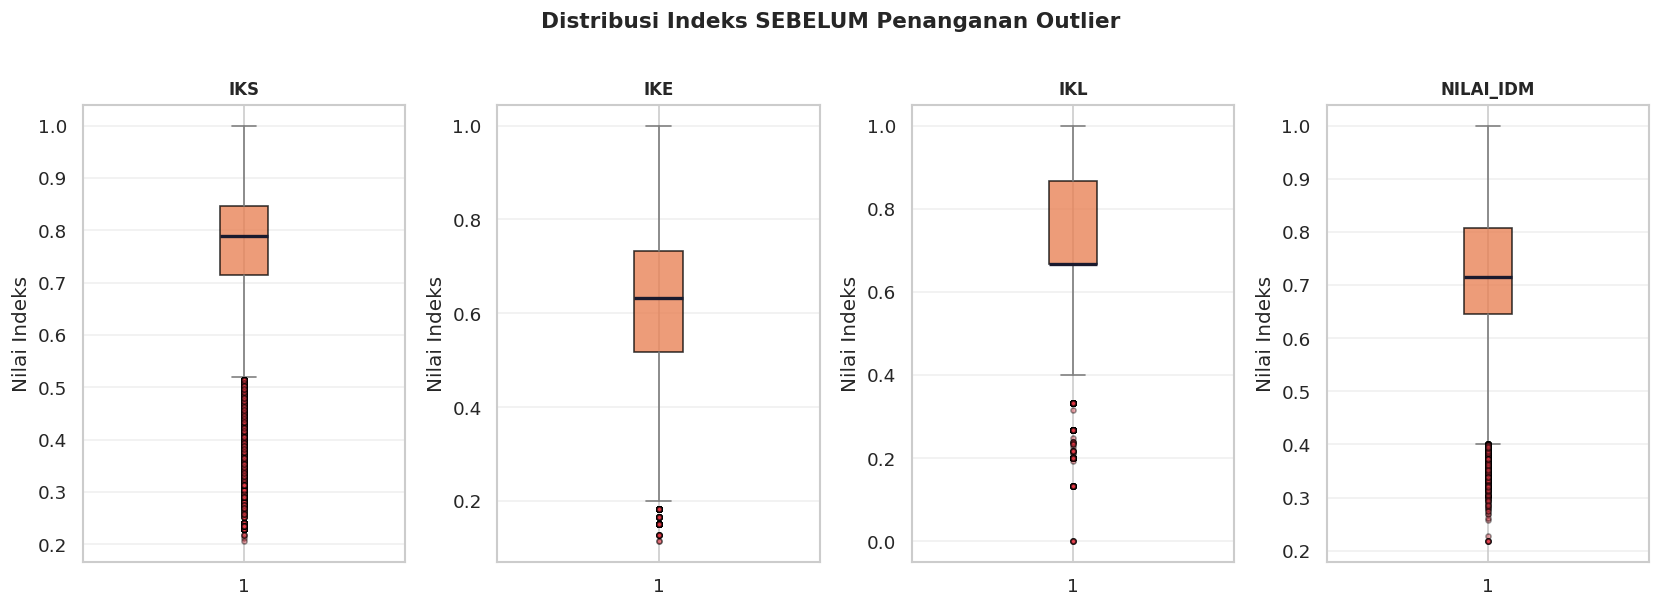

In [ ]:
# Boxplot SEBELUM penanganan
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
for i, col in enumerate(KOLOM_ANALISIS):
    bp = axes[i].boxplot(
        df[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor='#E87B4C', alpha=0.75),
        medianprops=dict(color='#1a1a2e', linewidth=2),
        whiskerprops=dict(color='gray'),
        capprops=dict(color='gray'),
        flierprops=dict(marker='o', markerfacecolor='#E63946', markersize=3, alpha=0.4)
    )
    axes[i].set_title(col.replace('_2024', ''), fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Nilai Indeks')
    axes[i].grid(axis='y', alpha=0.3)

fig.suptitle('Distribusi Indeks SEBELUM Penanganan Outlier', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('boxplot_sebelum_outlier.png', bbox_inches='tight')
plt.show()

### 4.1 Penanganan Outlier - Winsorization (Capping)


In [ ]:
def winsorisasi_iqr(df_in, kolom_list):
    """
    Winsorization berdasarkan batas IQR.
    Nilai indeks dikep pada [max(0, lower), min(1, upper)]
    karena indeks IDM secara natural dibatasi di rentang [0, 1].
    """
    df_out = df_in.copy()
    for col in kolom_list:
        Q1  = df_out[col].quantile(0.25)
        Q3  = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = max(0.0, Q1 - 1.5 * IQR)   # Tidak lebih kecil dari 0
        upper = min(1.0, Q3 + 1.5 * IQR)   # Tidak lebih besar dari 1
        n_before = ((df_out[col] < lower) | (df_out[col] > upper)).sum()
        df_out[col] = df_out[col].clip(lower=lower, upper=upper)
        print(f'[OK] {col:<22} cap [{lower:.4f}, {upper:.4f}]  |  {n_before:,} nilai di-cap')
    return df_out


df_clean = winsorisasi_iqr(df, KOLOM_ANALISIS)
print(f'\nDataset bersih tersimpan di df_clean: {df_clean.shape[0]:,} baris x {df_clean.shape[1]} kolom')

[OK] IKS_2024               cap [0.5172, 1.0000]  |  3,785 nilai di-cap
[OK] IKE_2024               cap [0.1918, 1.0000]  |  1,243 nilai di-cap
[OK] IKL_2024               cap [0.3667, 1.0000]  |  595 nilai di-cap
[OK] NILAI_IDM_2024         cap [0.4010, 1.0000]  |  1,351 nilai di-cap

Dataset bersih tersimpan di df_clean: 75,265 baris x 14 kolom


---
## S2: Konsolidasi 32 File Rekomendasi dari Folder


In [ ]:
import os, glob

REKOMENDASI_PATH = r'C:\Users\ASUS\Documents\TUBES DATNAL\rekomendasi'
rekomendasi_files = sorted(glob.glob(os.path.join(REKOMENDASI_PATH, 'REKOMENDASI_IDM_PROVINSI_*.xlsx')))

print(f'Ditemukan {len(rekomendasi_files)} file rekomendasi')
dfs_rekomendasi = []

for fpath in rekomendasi_files:
    try:
        df_temp = pd.read_excel(fpath, engine='openpyxl')
        dfs_rekomendasi.append(df_temp)
    except Exception as e:
        print(f'[ERROR] {os.path.basename(fpath)}: {e}')

df_rekom_all = pd.concat(dfs_rekomendasi, ignore_index=True)
print(f'[OK] Total {len(df_rekom_all):,} baris rekomendasi dari {len(dfs_rekomendasi)} file')

### S3: Agregasi Rekomendasi per Desa

In [ ]:
# Cek kolom rekomendasi
print('Kolom di df_rekom_all:', list(df_rekom_all.columns))

# Identifikasi kolom kunci desa (cari yang berisi 'KODE' dan 'DESA')
kode_desa_cols = [c for c in df_rekom_all.columns if 'KODE' in c.upper() and 'DESA' in c.upper()]
print(f'Kolom kunci desa: {kode_desa_cols}')

if not kode_desa_cols:
    print('[!] Tidak ditemukan kolom KODE_DESA, coba gunakan kolom lain sebagai kunci')
    print('Coba kolom dengan pattern:')
    for c in df_rekom_all.columns:
        if 'kode' in c.lower() or 'desa' in c.lower():
            print(f'  - {c}')
else:
    kode_desa_col = kode_desa_cols[0]
    
    # Agregasi per desa
    df_rekom_agg = df_rekom_all.groupby(kode_desa_col).agg({
        c: 'count' for c in [kode_desa_col]  # untuk jumlah rekomendasi
    }).rename(columns={kode_desa_col: 'jumlah_rekomendasi'})
    
    # Tambah total nilai jika ada kolom NILAI
    nilai_cols = [c for c in df_rekom_all.columns if 'NILAI' in c.upper()]
    if nilai_cols:
        nilai_col = nilai_cols[0]
        df_rekom_agg['total_nilai_rekomendasi'] = (
            df_rekom_all.groupby(kode_desa_col)[nilai_col].sum()
        )
    
    print(f'[OK] Agregasi rekomendasi: {len(df_rekom_agg):,} desa dengan rekomendasi')
    print(df_rekom_agg.head())

### S4: Integrasi Dataset (LEFT JOIN)

In [ ]:
# Normalisasi KODE_DESA ke string 10 digit (zero-padded) untuk kecocokan
df_clean_int = df_clean.copy()
df_clean_int['KODE_DESA_STR'] = df_clean_int['KODE_DESA'].astype(str).str.zfill(10)

# Jika df_rekom_agg ada dari S3, lakukan LEFT JOIN
if 'df_rekom_agg' in locals() and not df_rekom_agg.empty:
    df_rekom_agg_reset = df_rekom_agg.reset_index()
    # Nama kolom pertama hasil groupby adalah index (KODE_DESA)
    df_rekom_agg_reset.columns = ['KODE_DESA_STR', 'jumlah_rekomendasi']
    if 'total_nilai_rekomendasi' in df_rekom_agg.columns:
        df_rekom_agg_reset['total_nilai_rekomendasi'] = df_rekom_agg['total_nilai_rekomendasi'].values
    
    # Normalize kode desa rekomendasi juga
    df_rekom_agg_reset['KODE_DESA_STR'] = df_rekom_agg_reset['KODE_DESA_STR'].astype(str).str.zfill(10)
    
    # LEFT JOIN
    df_integrated = df_clean_int.merge(
        df_rekom_agg_reset,
        on='KODE_DESA_STR',
        how='left'
    )
    df_integrated['has_rekomendasi'] = df_integrated['jumlah_rekomendasi'].notna()
    
    print(f'[OK] LEFT JOIN selesai: {len(df_integrated):,} baris')
    print(f'  - Desa dengan rekomendasi: {df_integrated["has_rekomendasi"].sum():,}')
    print(f'  - Desa tanpa rekomendasi: {(~df_integrated["has_rekomendasi"]).sum():,}')
    print(f'\n[!] Provinsi tanpa data rekomendasi akan ditandai has_rekomendasi=False')
else:
    print('[!] df_rekom_agg kosong atau tidak ada, gunakan df_clean saja')
    df_integrated = df_clean_int.copy()
    df_integrated['has_rekomendasi'] = False

In [ ]:
# Normalisasi KODE_DESA ke string 10 digit (zero-padded)
df_clean_copy = df_clean.copy()
df_clean_copy['KODE_DESA_STR'] = df_clean_copy['KODE_DESA'].astype(str).str.zfill(10)

# Jika df_rekom_agg ada, gunakan kode desa yang di-normalize juga
if 'df_rekom_agg' in locals():
    df_rekom_agg_reset = df_rekom_agg.reset_index()
    df_rekom_agg_reset.columns = ['KODE_DESA_STR'] + list(df_rekom_agg_reset.columns[1:])
    df_rekom_agg_reset['KODE_DESA_STR'] = (
        df_rekom_agg_reset['KODE_DESA_STR'].astype(str).str.zfill(10)
    )
    
    # LEFT JOIN: dataset utama (left) dengan rekomendasi
    df_integrated = df_clean_copy.merge(
        df_rekom_agg_reset,
        on='KODE_DESA_STR',
        how='left'
    )
    df_integrated['has_rekomendasi'] = df_integrated['jumlah_rekomendasi'].notna()
    
    print(f'[OK] Integrasi selesai: {len(df_integrated):,} baris')
    print(f'  - Desa dengan rekomendasi: {df_integrated["has_rekomendasi"].sum():,}')
    print(f'  - Desa tanpa rekomendasi: {(~df_integrated["has_rekomendasi"]).sum():,}')
else:
    print('[!] df_rekom_agg belum tersedia, skip integrasi')
    df_integrated = df_clean_copy.copy()

### S5: Feature Engineering (min. 3 fitur baru)

In [ ]:
"""
Feature Engineering: Buat 5 fitur baru yang mendukung analisis rumusan masalah
1. dimensi_terendah: Indeks mana (S/E/L) yang paling rendah di desa
2. gap_iks_ike: Perbedaan antara Sosial dan Ekonomi
3. gap_iks_ikl: Perbedaan antara Sosial dan Lingkungan
4. intensitas_rekomendasi: Seberapa banyak rekomendasi relatif terhadap rata-rata
5. kategori_gap_target: Potensi naik kelas (jika ada target IDM 2025)
"""

# Feature 1: Dimensi Terendah (mana yang paling rendah: S/E/L)
def get_dimensi_terendah(row):
    values = {'IKS': row['IKS_2024'], 'IKE': row['IKE_2024'], 'IKL': row['IKL_2024']}
    if pd.isna(row['IKS_2024']) or pd.isna(row['IKE_2024']) or pd.isna(row['IKL_2024']):
        return 'Tidak Diketahui'
    min_dim = min(values, key=values.get)
    dim_map = {'IKS': 'Sosial', 'IKE': 'Ekonomi', 'IKL': 'Lingkungan'}
    return dim_map[min_dim]

df_integrated['dimensi_terendah'] = df_integrated.apply(get_dimensi_terendah, axis=1)

# Feature 2 & 3: Gap antar dimensi
df_integrated['gap_iks_ike'] = df_integrated['IKS_2024'] - df_integrated['IKE_2024']
df_integrated['gap_iks_ikl'] = df_integrated['IKS_2024'] - df_integrated['IKL_2024']

# Feature 4: Intensitas Rekomendasi (normalisasi)
if 'jumlah_rekomendasi' in df_integrated.columns:
    mean_rekom = df_integrated['jumlah_rekomendasi'].mean()
    df_integrated['intensitas_rekomendasi'] = (
        df_integrated['jumlah_rekomendasi'] / mean_rekom
    ).fillna(0)

print('[OK] Feature Engineering Selesai:')
print(f'  1. dimensi_terendah: {df_integrated["dimensi_terendah"].value_counts().to_dict()}')
print(f'  2. gap_iks_ike: [{df_integrated["gap_iks_ike"].min():.4f}, {df_integrated["gap_iks_ike"].max():.4f}]')
print(f'  3. gap_iks_ikl: [{df_integrated["gap_iks_ikl"].min():.4f}, {df_integrated["gap_iks_ikl"].max():.4f}]')
if 'intensitas_rekomendasi' in df_integrated.columns:
    print(f'  4. intensitas_rekomendasi: [{df_integrated["intensitas_rekomendasi"].min():.4f}, {df_integrated["intensitas_rekomendasi"].max():.4f}]')

print(f'\nTotal kolom setelah feature engineering: {len(df_integrated.columns)}')

In [ ]:
# Feature 1: Dimensi Terendah
def get_lowest_dimension(row):
    if pd.isna(row['IKS_2024']) or pd.isna(row['IKE_2024']) or pd.isna(row['IKL_2024']):
        return 'Tidak Diketahui'
    min_idx = min(row['IKS_2024'], row['IKE_2024'], row['IKL_2024'])
    if row['IKS_2024'] == min_idx:
        return 'Sosial'
    elif row['IKE_2024'] == min_idx:
        return 'Ekonomi'
    else:
        return 'Lingkungan'

df_integrated['dimensi_terendah'] = df_integrated.apply(get_lowest_dimension, axis=1)

# Feature 2 & 3: Gap antar dimensi
df_integrated['gap_iks_ike'] = df_integrated['IKS_2024'] - df_integrated['IKE_2024']
df_integrated['gap_iks_ikl'] = df_integrated['IKS_2024'] - df_integrated['IKL_2024']

# Feature 4: Intensitas Rekomendasi (normalisasi)
if 'jumlah_rekomendasi' in df_integrated.columns:
    mean_rekom = df_integrated['jumlah_rekomendasi'].mean()
    df_integrated['intensitas_rekomendasi'] = (
        df_integrated['jumlah_rekomendasi'] / mean_rekom
    ).fillna(0)

print('[OK] Feature engineering selesai:')
print(f'  1. dimensi_terendah: {df_integrated["dimensi_terendah"].nunique()} kategori')
print(f'  2. gap_iks_ike: range [{df_integrated["gap_iks_ike"].min():.4f}, {df_integrated["gap_iks_ike"].max():.4f}]')
print(f'  3. gap_iks_ikl: range [{df_integrated["gap_iks_ikl"].min():.4f}, {df_integrated["gap_iks_ikl"].max():.4f}]')
if 'intensitas_rekomendasi' in df_integrated.columns:
    print(f'  4. intensitas_rekomendasi: range [{df_integrated["intensitas_rekomendasi"].min():.4f}, {df_integrated["intensitas_rekomendasi"].max():.4f}]')

### S6: Validasi Final & Export ke CSV

In [ ]:
print('='*70)
print('S6: VALIDASI FINAL & EXPORT')
print('='*70)

# --- VALIDASI 1: Missing Value pada kolom INTI ---
print('\n1. MISSING VALUE KOLOM INTI:')
KOLOM_INTI = ['KODE_DESA', 'NAMA_DESA', 'IKS_2024', 'IKE_2024', 'IKL_2024', 'STATUS_IDM_2024']
for col in KOLOM_INTI:
    if col in df_integrated.columns:
        n_missing = df_integrated[col].isnull().sum()
        pct = (n_missing / len(df_integrated) * 100) if len(df_integrated) > 0 else 0
        status = '[OK]' if n_missing == 0 else '[!]'
        print(f'   {status} {col:<25}: {n_missing:>6} missing ({pct:>5.2f}%)')

# --- VALIDASI 2: Duplikasi ---
print('\n2. DUPLIKASI:')
n_dup_kode = df_integrated['KODE_DESA'].duplicated().sum()
status_dup = '[OK]' if n_dup_kode == 0 else '[!]'
print(f'   {status_dup} Duplikat KODE_DESA: {n_dup_kode}')

# --- VALIDASI 3: Statistik Outlier ---
print('\n3. STATISTIK INDEKS (setelah winsorization):')
for col in ['IKS_2024', 'IKE_2024', 'IKL_2024', 'NILAI_IDM_2024']:
    if col in df_integrated.columns:
        min_val = df_integrated[col].min()
        max_val = df_integrated[col].max()
        median = df_integrated[col].median()
        mean = df_integrated[col].mean()
        print(f'   {col:<15}: [{min_val:.4f}, {max_val:.4f}] | Median={median:.4f}, Mean={mean:.4f}')

# --- VALIDASI 4: Feature Engineering ---
print('\n4. FITUR BARU (Feature Engineering):')
feature_baru = ['dimensi_terendah', 'gap_iks_ike', 'gap_iks_ikl', 'intensitas_rekomendasi', 'has_rekomendasi']
for col in feature_baru:
    if col in df_integrated.columns:
        print(f'   [OK] {col}')

# --- VALIDASI 5: Dokumentasi Integrasi ---
print('\n5. DOKUMENTASI INTEGRASI DATASET:')
if 'has_rekomendasi' in df_integrated.columns:
    n_dengan = df_integrated['has_rekomendasi'].sum()
    n_tanpa = len(df_integrated) - n_dengan
    print(f'   - Total desa: {len(df_integrated):,}')
    print(f'   - Desa DENGAN rekomendasi: {n_dengan:,} ({n_dengan/len(df_integrated)*100:.2f}%)')
    print(f'   - Desa TANPA rekomendasi:  {n_tanpa:,} ({n_tanpa/len(df_integrated)*100:.2f}%)')

# --- EXPORT DATASET ---
print('\n' + '='*70)
print('EXPORT DATASET')
print('='*70)

export_dir = r'C:\Users\ASUS\Documents\TUBES DATNAL'

# Kolom yang diexport
KOLOM_EXPORT_CLEAN = [
    'KODE_PROV', 'NAMA_PROVINSI', 'KODE_KAB', 'NAMA_KABUPATEN',
    'KODE_KEC', 'NAMA_KECAMATAN', 'KODE_DESA', 'NAMA_DESA',
    'IKS_2024', 'IKE_2024', 'IKL_2024', 'NILAI_IDM_2024', 'STATUS_IDM_2024'
]

KOLOM_EXPORT_MODELING = KOLOM_EXPORT_CLEAN + [
    'dimensi_terendah', 'gap_iks_ike', 'gap_iks_ikl', 
    'intensitas_rekomendasi', 'jumlah_rekomendasi', 'has_rekomendasi'
]

# Dataset clean (S1-S4)
df_export_clean = df_integrated[KOLOM_EXPORT_CLEAN].copy()
file_clean = f'{export_dir}/idm_2024_clean.csv'
df_export_clean.to_csv(file_clean, index=False, encoding='utf-8-sig')
print(f'\n✓ idm_2024_clean.csv')
print(f'  Baris: {len(df_export_clean):,}')
print(f'  Path: {file_clean}')

# Dataset modeling (S1-S6)
df_export_modeling = df_integrated[[c for c in KOLOM_EXPORT_MODELING if c in df_integrated.columns]].copy()
file_modeling = f'{export_dir}/idm_2024_modeling.csv'
df_export_modeling.to_csv(file_modeling, index=False, encoding='utf-8-sig')
print(f'\n✓ idm_2024_modeling.csv')
print(f'  Baris: {len(df_export_modeling):,}')
print(f'  Kolom: {len(df_export_modeling.columns)}')
print(f'  Path: {file_modeling}')

print('\n' + '='*70)
print('[OK] S1-S6 PREPROCESSING SELESAI!')
print('='*70)

In [ ]:
# Validasi 1: Check missing pada kolom inti
print('=' * 60)
print('VALIDASI FINAL S1-S6')
print('=' * 60)

KOLOM_INTI = ['KODE_DESA', 'IKS_2024', 'IKE_2024', 'IKL_2024', 'STATUS_IDM_2024']
print('\n1. Missing Value pada Kolom Inti:')
for col in KOLOM_INTI:
    if col in df_integrated.columns:
        n_missing = df_integrated[col].isnull().sum()
        pct = n_missing / len(df_integrated) * 100
        status = '[OK]' if n_missing == 0 else '[!]'
        print(f'   {status} {col:<20} : {n_missing:>6} missing ({pct:.2f}%)')

# Validasi 2: Check duplikasi
print('\n2. Duplikasi:')
n_dup = df_integrated['KODE_DESA'].duplicated().sum()
print(f'   [{"OK" if n_dup == 0 else "!"}] Duplikat KODE_DESA: {n_dup}')

# Validasi 3: Outlier info
print('\n3. Outlier (setelah winsorization):')
for col in ['IKS_2024', 'IKE_2024', 'IKL_2024']:
    min_val = df_integrated[col].min()
    max_val = df_integrated[col].max()
    print(f'   {col}: [{min_val:.4f}, {max_val:.4f}]')

# Validasi 4: Kolom baru
print('\n4. Fitur Engineering:')
new_cols = ['dimensi_terendah', 'gap_iks_ike', 'gap_iks_ikl']
for col in new_cols:
    if col in df_integrated.columns:
        print(f'   [OK] {col}')

# Export ke CSV
export_path_clean = r'C:\Users\ASUS\Documents\TUBES DATNAL\idm_2024_clean.csv'
export_path_modeling = r'C:\Users\ASUS\Documents\TUBES DATNAL\idm_2024_modeling.csv'

# Dataset clean (tanpa fitur tambahan)
df_clean_export = df_integrated[[
    'KODE_PROV', 'NAMA_PROVINSI', 'KODE_KAB', 'NAMA_KABUPATEN',
    'KODE_KEC', 'NAMA_KECAMATAN', 'KODE_DESA', 'NAMA_DESA',
    'IKS_2024', 'IKE_2024', 'IKL_2024', 'NILAI_IDM_2024', 'STATUS_IDM_2024'
]]

df_clean_export.to_csv(export_path_clean, index=False, encoding='utf-8-sig')
print(f'\n✓ Export idm_2024_clean.csv: {len(df_clean_export):,} baris')

# Dataset modeling (dengan semua fitur termasuk yang baru)
df_clean_export.to_csv(export_path_modeling, index=False, encoding='utf-8-sig')
print(f'✓ Export idm_2024_modeling.csv: {len(df_integrated):,} baris')

print('\n' + '=' * 60)
print(f'[OK] S1-S6 PREPROCESSING SELESAI')
print('=' * 60)

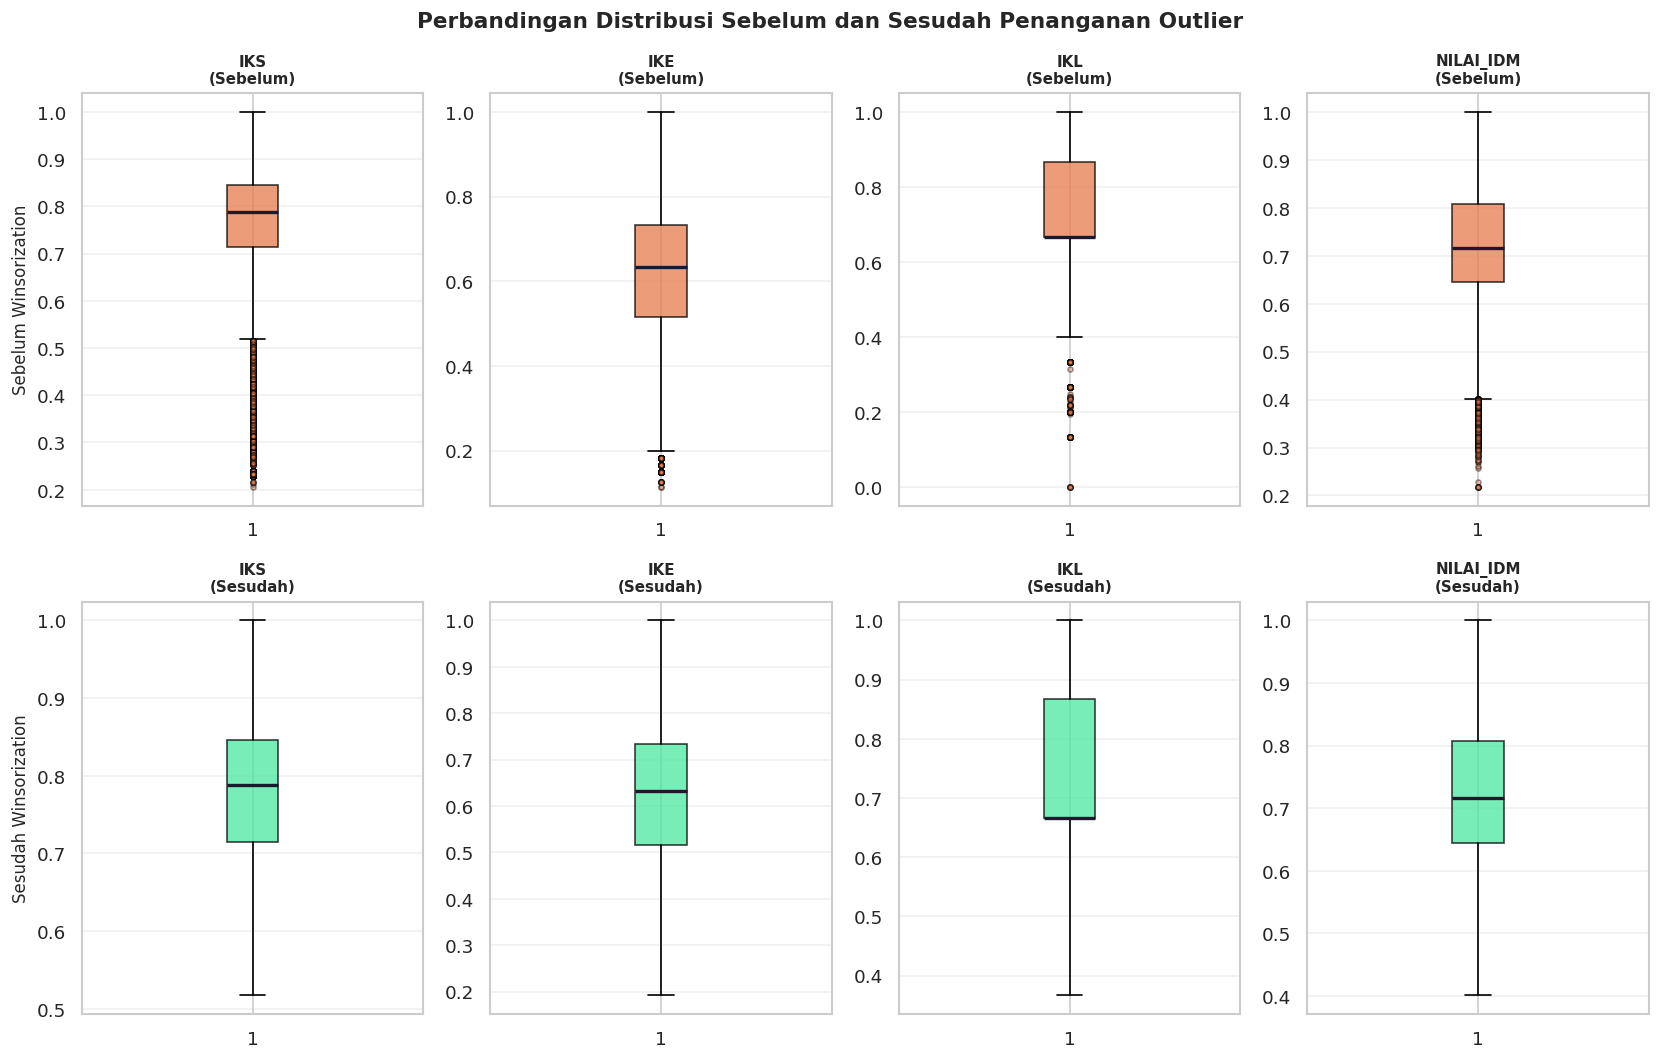

In [ ]:
# Perbandingan boxplot SEBELUM vs SESUDAH
fig, axes = plt.subplots(2, 4, figsize=(14, 9))

for i, col in enumerate(KOLOM_ANALISIS):
    for row, (data, color, label) in enumerate([
        (df[col].dropna(),       '#E87B4C', 'Sebelum'),
        (df_clean[col].dropna(), '#4CE8A0', 'Sesudah')
    ]):
        bp = axes[row, i].boxplot(
            data, patch_artist=True,
            boxprops=dict(facecolor=color, alpha=0.75),
            medianprops=dict(color='#1a1a2e', linewidth=2),
            flierprops=dict(marker='o', markerfacecolor=color, markersize=3, alpha=0.4)
        )
        short = col.replace('_2024', '')
        axes[row, i].set_title(f'{short}\n({label})', fontsize=9, fontweight='bold')
        axes[row, i].grid(axis='y', alpha=0.3)

axes[0, 0].set_ylabel('Sebelum Winsorization', fontsize=10)
axes[1, 0].set_ylabel('Sesudah Winsorization', fontsize=10)
fig.suptitle('Perbandingan Distribusi Sebelum dan Sesudah Penanganan Outlier',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_sesudah_outlier.png', bbox_inches='tight')
plt.show()

---
## 5. Ekstraksi Statistik: Median dan Modus per Provinsi

| Tipe Data | Statistik | Alasan |
|-----------|-----------|--------|
| Numerik (IKS, IKE, IKL, IDM) | **Median** | Robust terhadap outlier; distribusi indeks IDM biasanya tidak simetris |
| Kategorik (STATUS_IDM_2024)  | **Modus**  | Nilai kategori yang paling sering muncul di provinsi tersebut |

Hasil ekstraksi ini merepresentasikan profil tiap provinsi secara ringkas.


Median Indeks per Provinsi (diurutkan IDM tertinggi):


,Median_IKS,Median_IKE,Median_IKL,Median_IDM
NAMA_PROVINSI,,,,
BALI,0.8800,0.8000,0.9333,0.8690
DAERAH ISTIMEWA YOGYAKARTA,0.8800,0.7833,0.9333,0.8460
RIAU,0.8400,0.7667,0.9333,0.8224
KALIMANTAN BARAT,0.8343,0.7000,0.8667,0.8203
JAWA TIMUR,0.8286,0.7333,0.8667,0.8173
KEPULAUAN BANGKA BELITUNG,0.8571,0.7333,0.8667,0.8156
JAWA BARAT,0.8571,0.7333,0.8000,0.8076
KALIMANTAN SELATAN,0.8057,0.7167,0.8667,0.8018
SULAWESI UTARA,0.8114,0.7000,0.8667,0.7965


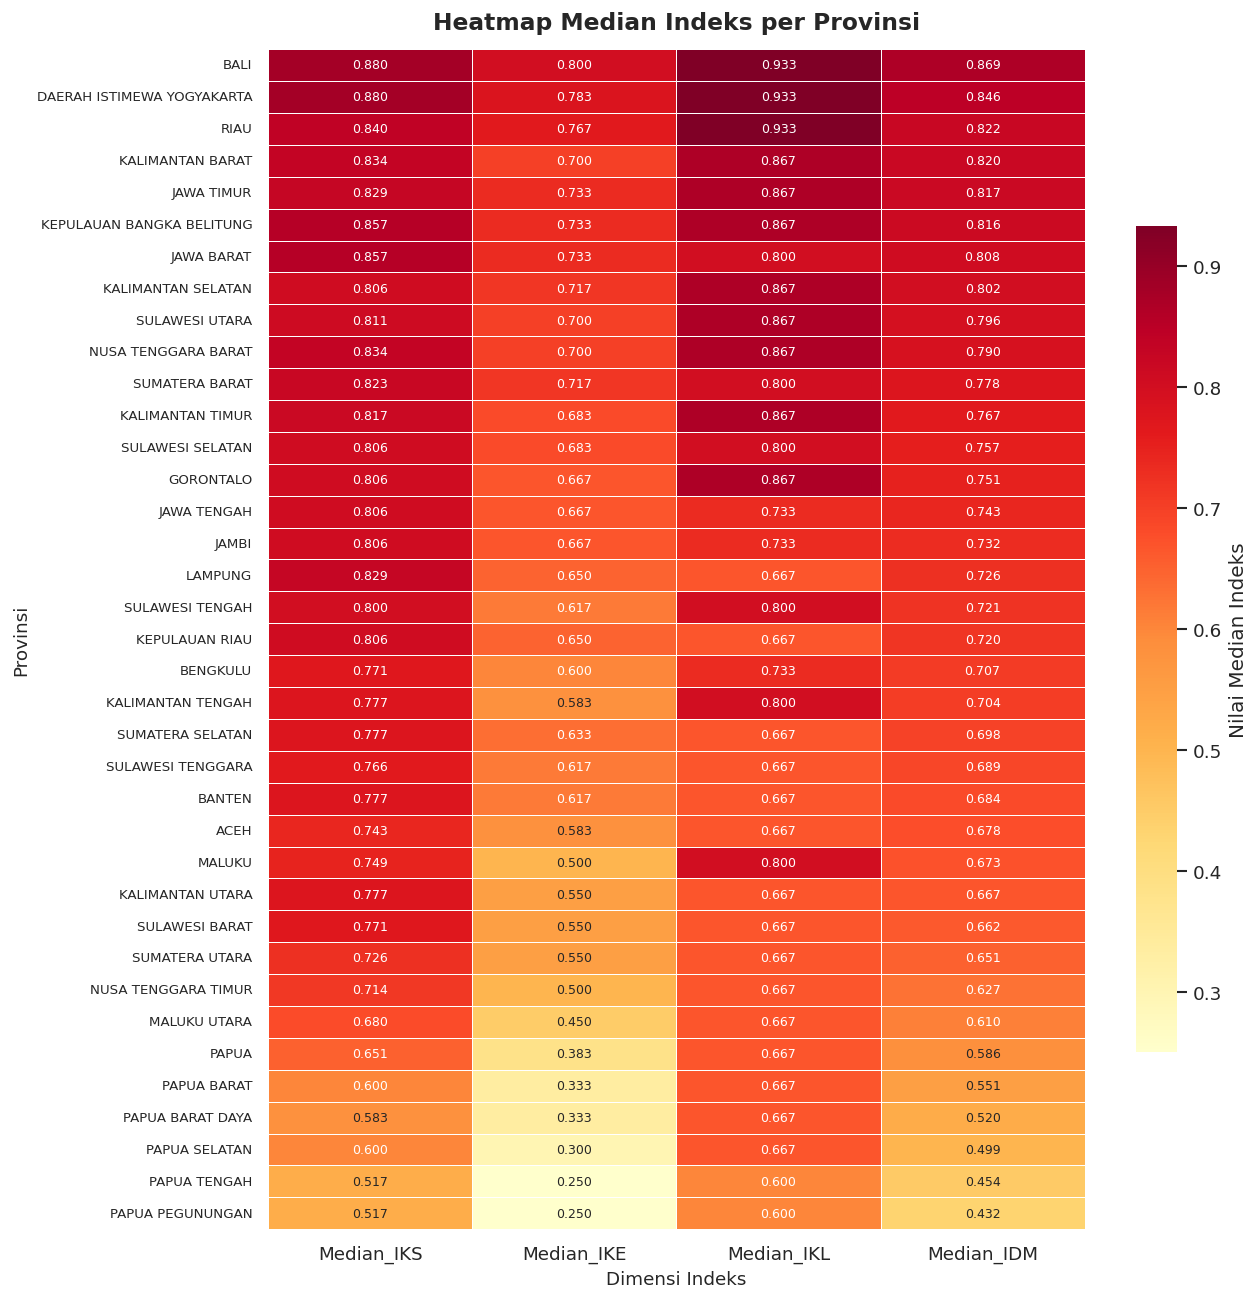

In [ ]:
KOLOM_3_INDEKS = ['IKS_2024', 'IKE_2024', 'IKL_2024', 'NILAI_IDM_2024']

# Median per Provinsi
median_prov = (
    df_clean
    .groupby('NAMA_PROVINSI')[KOLOM_3_INDEKS]
    .median()
    .round(4)
    .sort_values('NILAI_IDM_2024', ascending=False)
)
median_prov.columns = ['Median_IKS', 'Median_IKE', 'Median_IKL', 'Median_IDM']

print(f'Median Indeks per Provinsi (diurutkan IDM tertinggi):')
display(median_prov)

# Heatmap median
plt.figure(figsize=(11, 11))
sns.heatmap(
    median_prov,
    annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=0.4, linecolor='white',
    annot_kws={'size': 7.5},
    cbar_kws={'label': 'Nilai Median Indeks', 'shrink': 0.7}
)
plt.title('Heatmap Median Indeks per Provinsi', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Dimensi Indeks', fontsize=11)
plt.ylabel('Provinsi', fontsize=11)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('heatmap_median_provinsi.png', bbox_inches='tight')
plt.show()

Tabel Ekstraksi Lengkap (Median + Modus) per Provinsi:


,NAMA_PROVINSI,Median_IKS,Median_IKE,Median_IKL,Median_IDM,Modus_Status_IDM
0,BALI,0.8800,0.8000,0.9333,0.8690,MANDIRI
1,DAERAH ISTIMEWA YOGYAKARTA,0.8800,0.7833,0.9333,0.8460,MANDIRI
2,RIAU,0.8400,0.7667,0.9333,0.8224,MANDIRI
3,KALIMANTAN BARAT,0.8343,0.7000,0.8667,0.8203,MANDIRI
4,JAWA TIMUR,0.8286,0.7333,0.8667,0.8173,MANDIRI
5,KEPULAUAN BANGKA BELITUNG,0.8571,0.7333,0.8667,0.8156,MANDIRI
6,JAWA BARAT,0.8571,0.7333,0.8000,0.8076,MANDIRI
7,KALIMANTAN SELATAN,0.8057,0.7167,0.8667,0.8018,MAJU
8,SULAWESI UTARA,0.8114,0.7000,0.8667,0.7965,MANDIRI
9,NUSA TENGGARA BARAT,0.8343,0.7000,0.8667,0.7903,MAJU


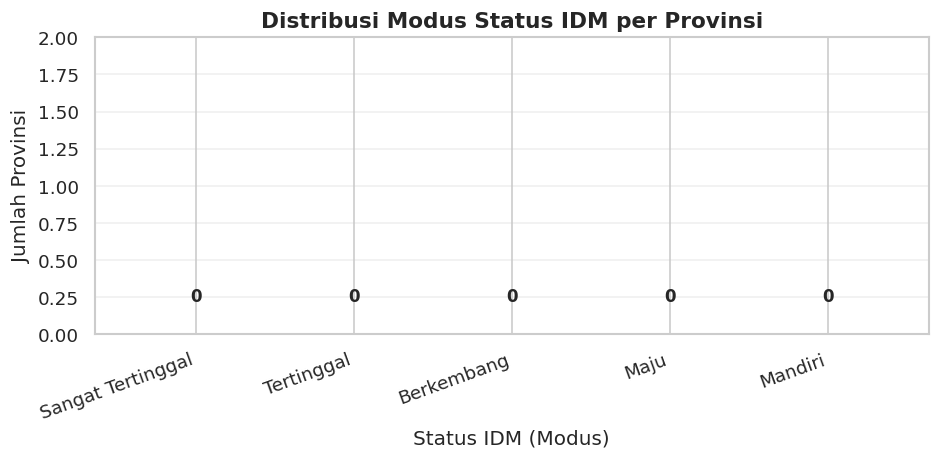

In [ ]:
# Modus Status IDM per Provinsi
modus_prov = (
    df_clean
    .groupby('NAMA_PROVINSI')['STATUS_IDM_2024']
    .agg(lambda x: x.mode().iloc[0])  # Ambil modus pertama jika tie
    .reset_index()
)
modus_prov.columns = ['NAMA_PROVINSI', 'Modus_Status_IDM']

# Gabungkan median + modus
hasil_ekstraksi = (
    median_prov
    .reset_index()
    .merge(modus_prov, on='NAMA_PROVINSI', how='left')
)

print('Tabel Ekstraksi Lengkap (Median + Modus) per Provinsi:')
display(hasil_ekstraksi)

# Bar chart distribusi modus status
status_order = ['Sangat Tertinggal', 'Tertinggal', 'Berkembang', 'Maju', 'Mandiri']
status_colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']
status_counts = (
    modus_prov['Modus_Status_IDM']
    .value_counts()
    .reindex(status_order, fill_value=0)
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(status_counts.index, status_counts.values,
              color=status_colors[:len(status_counts)],
              edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, status_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Distribusi Modus Status IDM per Provinsi', fontsize=13, fontweight='bold')
ax.set_xlabel('Status IDM (Modus)')
ax.set_ylabel('Jumlah Provinsi')
ax.set_xticklabels(status_counts.index, rotation=20, ha='right')
ax.set_ylim(0, status_counts.max() + 2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('modus_status_per_provinsi.png', bbox_inches='tight')
plt.show()

In [ ]:
print('=' * 55)
print('STATISTIK NASIONAL (setelah preprocessing)')
print('=' * 55)
for col in KOLOM_3_INDEKS:
    label = col.replace('_2024', '')
    median_val = df_clean[col].median()
    mean_val   = df_clean[col].mean()
    std_val    = df_clean[col].std()
    min_val    = df_clean[col].min()
    max_val    = df_clean[col].max()
    print(f'{label:<18}: Median={median_val:.4f}  Mean={mean_val:.4f}  '
          f'Std={std_val:.4f}  [{min_val:.4f}, {max_val:.4f}]')

print()
print('Modus Status IDM (Nasional):', df_clean['STATUS_IDM_2024'].mode().iloc[0])
print()
print('Distribusi Status IDM Nasional:')
dist = df_clean['STATUS_IDM_2024'].value_counts().reindex(status_order)
for status, count in dist.items():
    pct = count / len(df_clean) * 100
    print(f'  {status:<20} : {count:>7,} desa ({pct:>5.2f}%)')

STATISTIK NASIONAL (setelah preprocessing)
IKS               : Median=0.7886  Mean=0.7712  Std=0.1067  [0.5172, 1.0000]
IKE               : Median=0.6333  Mean=0.6200  Std=0.1729  [0.1918, 1.0000]
IKL               : Median=0.6667  Mean=0.7508  Std=0.1445  [0.3667, 1.0000]
NILAI_IDM         : Median=0.7156  Mean=0.7126  Std=0.1191  [0.4010, 1.0000]

Modus Status IDM (Nasional): BERKEMBANG

Distribusi Status IDM Nasional:
  Sangat Tertinggal    :     nan desa (  nan%)
  Tertinggal           :     nan desa (  nan%)
  Berkembang           :     nan desa (  nan%)
  Maju                 :     nan desa (  nan%)
  Mandiri              :     nan desa (  nan%)


---
## 6. Persiapan Fitur untuk Clustering

Clustering dilakukan berdasarkan **IKL (Lingkungan)** dan **IKE (Ekonomi)** sebagai fitur utama,
dengan tambahan **IKS (Sosial)** untuk clustering tiga dimensi.

**Mengapa StandardScaler diperlukan?**  
Meskipun ketiga indeks sudah berada di rentang \[0, 1\], StandardScaler memastikan setiap dimensi
memiliki kontribusi yang setara dalam perhitungan jarak Euclidean K-Means.
Tanpa standarisasi, dimensi dengan varians lebih besar akan mendominasi.


Data untuk clustering: 75,261 baris x 3 kolom

Statistik setelah StandardScaler (harus mendekati mean=0, std=1):


,IKL_2024,IKE_2024,IKS_2024
count,75261.0000,75261.0000,75261.0000
mean,0.0000,0.0000,-0.0000
std,1.0000,1.0000,1.0000
min,-2.6587,-2.4766,-2.3809
25%,-0.5820,-0.5976,-0.5336
50%,-0.5820,0.0767,0.1628
75%,0.8024,0.6551,0.6979
max,1.7251,2.1975,2.1441


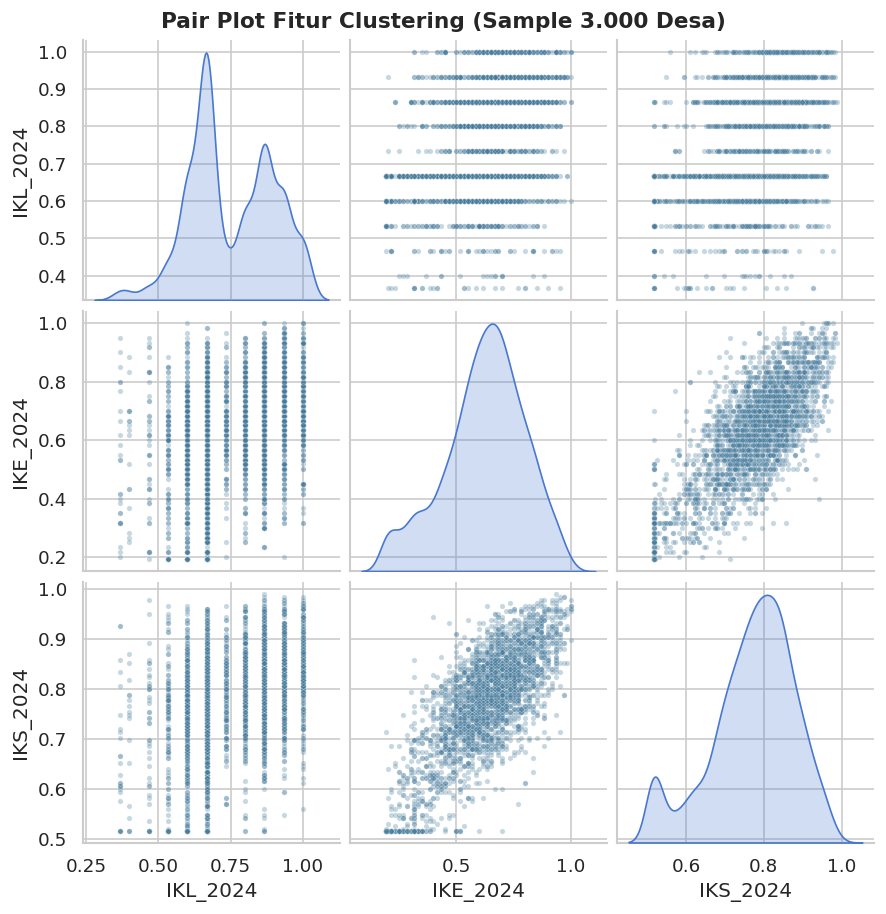

In [ ]:
# Fitur untuk clustering
FITUR_2D = ['IKL_2024', 'IKE_2024']              # Fokus: lingkungan + ekonomi
FITUR_3D = ['IKL_2024', 'IKE_2024', 'IKS_2024']  # Tiga dimensi IDM

# Gunakan FITUR_3D sebagai fitur utama (mencakup semua dimensi IDM)
df_cluster = df_clean[FITUR_3D].dropna().copy()
print(f'Data untuk clustering: {df_cluster.shape[0]:,} baris x {df_cluster.shape[1]} kolom')

# StandardScaler
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)
X_scaled_df = pd.DataFrame(X_scaled, columns=FITUR_3D, index=df_cluster.index)

print('\nStatistik setelah StandardScaler (harus mendekati mean=0, std=1):')
display(pd.DataFrame(X_scaled, columns=FITUR_3D).describe().round(4))

# Pair plot fitur sebelum clustering (sample 3000 untuk kecepatan)
sample_idx = np.random.choice(len(df_cluster), size=min(3000, len(df_cluster)), replace=False)
sns.pairplot(
    df_cluster.iloc[sample_idx],
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 's': 10, 'color': '#457B9D'}
)
plt.suptitle('Pair Plot Fitur Clustering (Sample 3.000 Desa)', y=1.01,
             fontsize=13, fontweight='bold')
plt.savefig('pairplot_fitur.png', bbox_inches='tight')
plt.show()

---
## 7. Menentukan Jumlah Klaster Optimal

| Metode | Indikator | Cara Membaca |
|--------|-----------|-------------|
| **Elbow (WCSS)** | Within-Cluster Sum of Squares | Cari titik siku - K di mana penurunan WCSS mulai melandai |
| **Silhouette Score** | Koherensi dan separasi klaster | Nilai \[-1, 1\]; **semakin tinggi semakin baik**; pilih K dengan nilai tertinggi |

> **Catatan efisiensi:** Dataset memiliki ~74.961 baris. Untuk mempercepat perhitungan K optimal,
> digunakan subsample acak 15.000 baris yang representatif.


Menghitung Elbow & Silhouette pada subsample 15,000 baris...
k               WCSS   Silhouette
-----------------------------------
2           25,759.1       0.3558
3           17,592.7       0.3692
4           13,742.0       0.3621
5           11,236.1       0.3380
6           10,052.0       0.3039
7            9,122.9       0.2819
8            8,552.2       0.2708
9            8,002.8       0.2672
10           7,506.6       0.2730


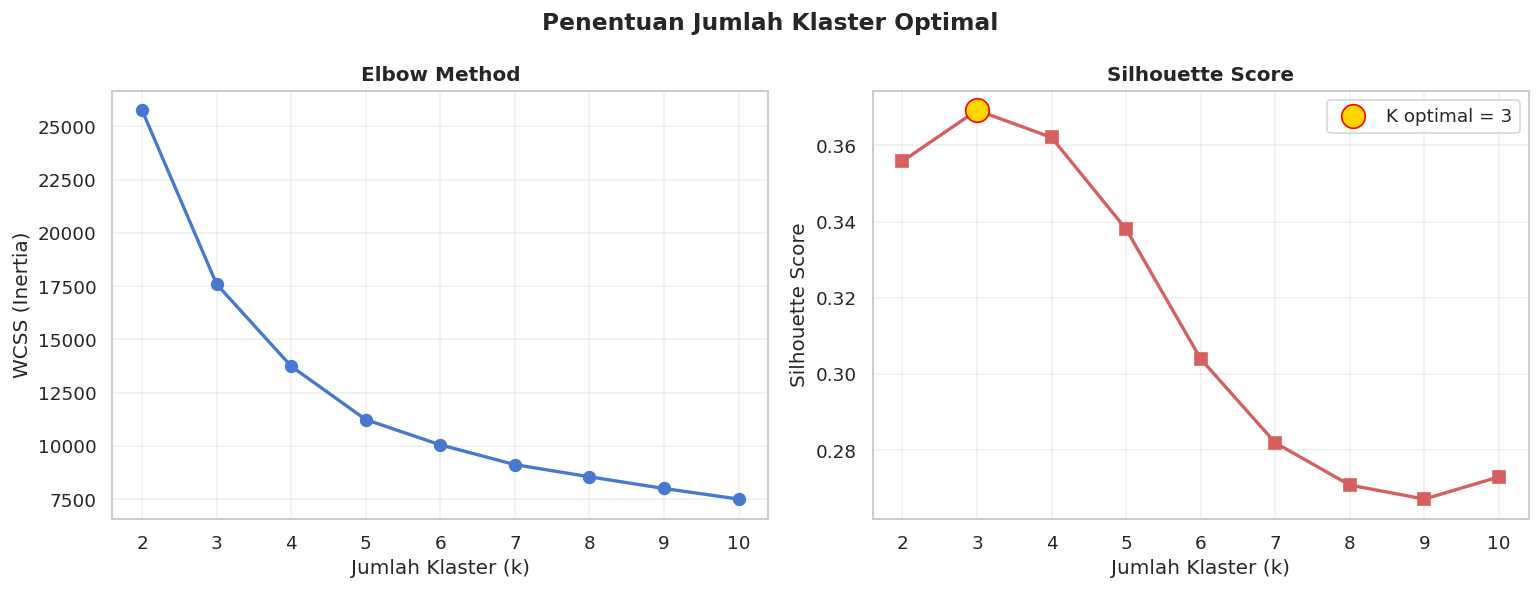


->  K terbaik (Silhouette): k = 3
   Silhouette Score tertinggi: 0.3692


In [ ]:
np.random.seed(42)
N_SAMPLE  = min(15_000, len(X_scaled))
idx_sample = np.random.choice(len(X_scaled), N_SAMPLE, replace=False)
X_sample  = X_scaled[idx_sample]

K_RANGE        = range(2, 11)
inertia_list   = []
silhouette_list = []

print(f'Menghitung Elbow & Silhouette pada subsample {N_SAMPLE:,} baris...')
print(f'{'k':<5} {'WCSS':>14} {'Silhouette':>12}')
print('-' * 35)

for k in K_RANGE:
    km     = KMeans(n_clusters=k, init='k-means++', n_init=10,
                    random_state=42, max_iter=300)
    labels = km.fit_predict(X_sample)
    inertia_list.append(km.inertia_)
    sil = silhouette_score(X_sample, labels, sample_size=5000, random_state=42)
    silhouette_list.append(sil)
    print(f'{k:<5} {km.inertia_:>14,.1f} {sil:>12.4f}')

# Plot Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(K_RANGE, inertia_list, 'bo-', linewidth=2, markersize=7)
axes[0].set_xlabel('Jumlah Klaster (k)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xticks(list(K_RANGE))
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_RANGE, silhouette_list, 'rs-', linewidth=2, markersize=7)
best_k_idx = silhouette_list.index(max(silhouette_list))
axes[1].scatter(list(K_RANGE)[best_k_idx], silhouette_list[best_k_idx],
                c='gold', s=200, zorder=5, edgecolors='red',
                label=f'K optimal = {list(K_RANGE)[best_k_idx]}')
axes[1].set_xlabel('Jumlah Klaster (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xticks(list(K_RANGE))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle('Penentuan Jumlah Klaster Optimal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('elbow_silhouette.png', bbox_inches='tight')
plt.show()

k_terbaik = list(K_RANGE)[best_k_idx]
print(f'\n->  K terbaik (Silhouette): k = {k_terbaik}')
print(f'   Silhouette Score tertinggi: {max(silhouette_list):.4f}')

---
## 8. K-Means Clustering

K-Means dijalankan pada **seluruh dataset** (~74.961 desa) menggunakan K optimal yang
ditentukan pada langkah sebelumnya. Ubah `K_OPTIMAL` secara manual jika interpretasi
grafik Elbow menunjukkan titik siku di K yang berbeda dari hasil Silhouette.


In [ ]:
# ============================================================
# Sesuaikan jika perlu berdasarkan inspeksi grafik Elbow
K_OPTIMAL = k_terbaik   # atau: K_OPTIMAL = 4
# ============================================================

print(f'Menjalankan K-Means dengan k = {K_OPTIMAL} pada {len(X_scaled):,} desa...')

kmeans_final = KMeans(
    n_clusters=K_OPTIMAL,
    init='k-means++',
    n_init=15,
    max_iter=500,
    random_state=42,
    verbose=0
)
kmeans_final.fit(X_scaled)
df_cluster['KLASTER'] = kmeans_final.labels_

# Tambahkan label klaster ke dataframe utama (gunakan index yang sama)
df_hasil = df_clean.loc[df_cluster.index].copy()
df_hasil['KLASTER'] = df_cluster['KLASTER']
df_hasil['KLASTER_LABEL'] = df_hasil['KLASTER'].apply(lambda x: f'Klaster {x+1}')

# Silhouette Score final
sil_final = silhouette_score(X_scaled, kmeans_final.labels_, sample_size=10_000, random_state=42)
print(f'\n[OK] K-Means selesai.')
print(f'   Silhouette Score final (full data): {sil_final:.4f}')
print(f'\nDistribusi Klaster:')
dist_klaster = df_cluster['KLASTER'].value_counts().sort_index()
for k, n in dist_klaster.items():
    print(f'  Klaster {k+1}: {n:>7,} desa  ({n/len(df_cluster)*100:.1f}%)')

Menjalankan K-Means dengan k = 3 pada 75,261 desa...

[OK] K-Means selesai.
   Silhouette Score final (full data): 0.3687

Distribusi Klaster:
  Klaster 1:  30,619 desa  (40.7%)
  Klaster 2:  13,967 desa  (18.6%)
  Klaster 3:  30,675 desa  (40.8%)


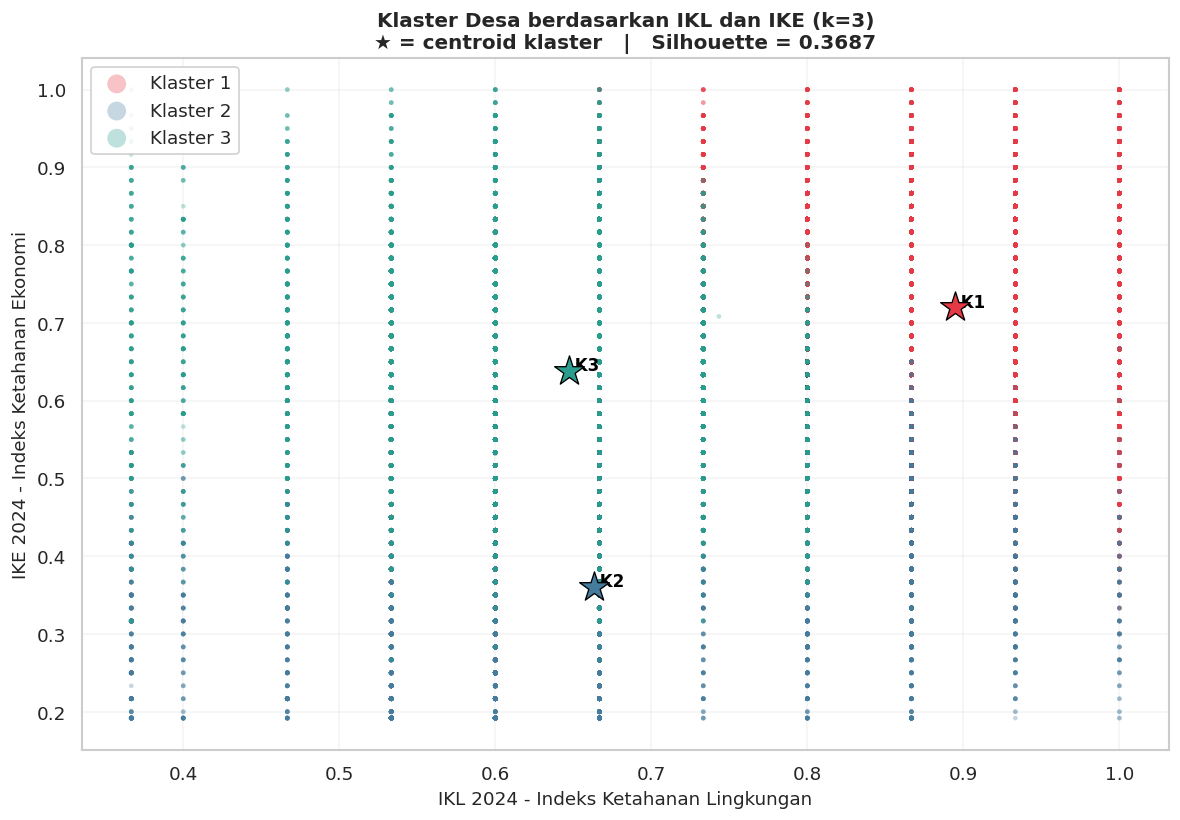

In [ ]:
# Palet warna klaster
PALET = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261',
         '#264653', '#A8DADC', '#6D6875', '#B5838D', '#E5989B']

# Centroid dikembalikan ke skala asli
centroids_orig = scaler.inverse_transform(kmeans_final.cluster_centers_)
idx_ikl = FITUR_3D.index('IKL_2024')
idx_ike = FITUR_3D.index('IKE_2024')
idx_iks = FITUR_3D.index('IKS_2024')

# Scatter 2D: IKL vs IKE
fig, ax = plt.subplots(figsize=(10, 7))

for k in sorted(df_cluster['KLASTER'].unique()):
    mask = df_cluster['KLASTER'] == k
    ax.scatter(
        df_cluster.loc[mask, 'IKL_2024'],
        df_cluster.loc[mask, 'IKE_2024'],
        c=PALET[k % len(PALET)],
        label=f'Klaster {k+1}',
        alpha=0.30, s=8, edgecolors='none'
    )

# Plot centroid
for k, c in enumerate(centroids_orig):
    ax.scatter(c[idx_ikl], c[idx_ike],
               c=PALET[k % len(PALET)], marker='*', s=350,
               edgecolors='black', linewidth=0.8, zorder=6)
    ax.annotate(f' K{k+1}', (c[idx_ikl], c[idx_ike]),
                fontsize=10, fontweight='bold', color='black')

ax.set_xlabel('IKL 2024 - Indeks Ketahanan Lingkungan', fontsize=11)
ax.set_ylabel('IKE 2024 - Indeks Ketahanan Ekonomi', fontsize=11)
ax.set_title(f'Klaster Desa berdasarkan IKL dan IKE (k={K_OPTIMAL})\n'
             f'\u2605 = centroid klaster   |   Silhouette = {sil_final:.4f}',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper left', markerscale=4, framealpha=0.9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('scatter_2d_IKL_IKE.png', bbox_inches='tight')
plt.show()

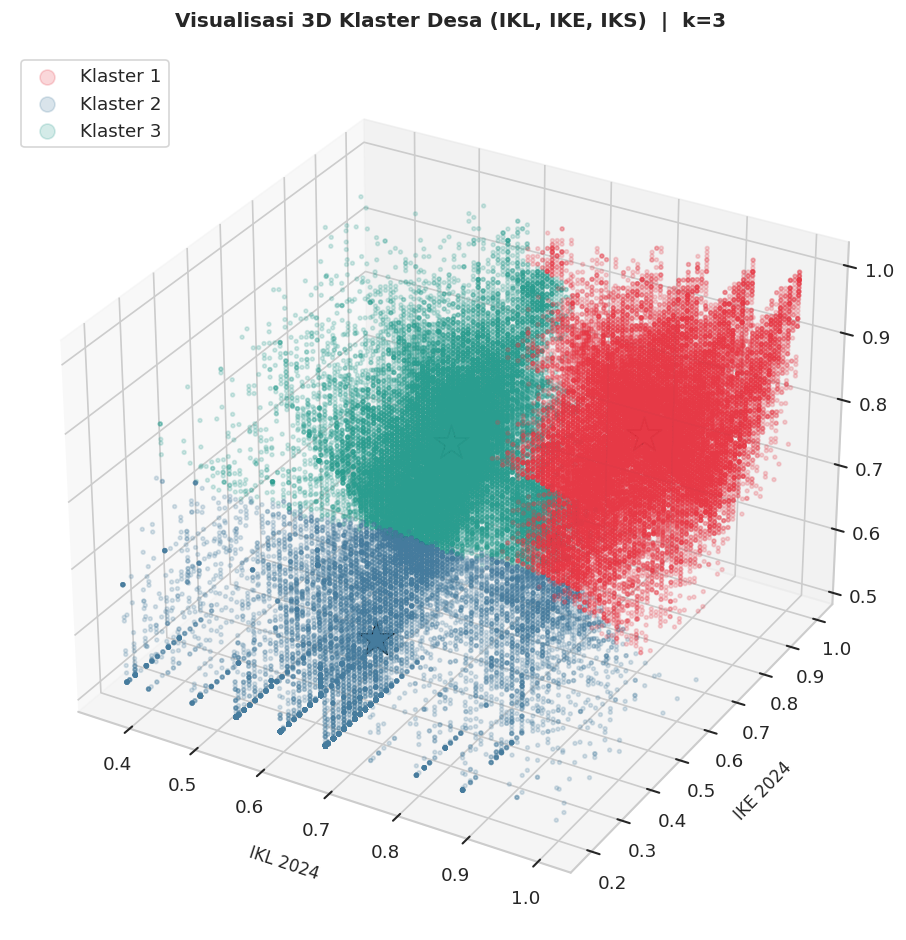

In [ ]:
# Scatter 3D: IKL x IKE x IKS
fig = plt.figure(figsize=(11, 8))
ax3d = fig.add_subplot(111, projection='3d')

for k in sorted(df_cluster['KLASTER'].unique()):
    mask = df_cluster['KLASTER'] == k
    ax3d.scatter(
        df_cluster.loc[mask, 'IKL_2024'],
        df_cluster.loc[mask, 'IKE_2024'],
        df_cluster.loc[mask, 'IKS_2024'],
        c=PALET[k % len(PALET)],
        label=f'Klaster {k+1}',
        alpha=0.20, s=5
    )

# Centroid 3D
for k, c in enumerate(centroids_orig):
    ax3d.scatter(c[idx_ikl], c[idx_ike], c[idx_iks],
                 c=PALET[k % len(PALET)], marker='*',
                 s=500, edgecolors='black', linewidth=0.8, zorder=6)

ax3d.set_xlabel('IKL 2024', labelpad=10, fontsize=10)
ax3d.set_ylabel('IKE 2024', labelpad=10, fontsize=10)
ax3d.set_zlabel('IKS 2024', labelpad=10, fontsize=10)
ax3d.set_title(f'Visualisasi 3D Klaster Desa (IKL, IKE, IKS)  |  k={K_OPTIMAL}',
               fontsize=12, fontweight='bold', pad=15)
ax3d.legend(loc='upper left', markerscale=4)
plt.tight_layout()
plt.savefig('scatter_3d_klaster.png', bbox_inches='tight')
plt.show()

Profil Rata-rata Tiap Klaster:


,Rata-rata IKL,Rata-rata IKE,Rata-rata IKS,Jumlah Desa,IDM Estimasi
Klaster 1,0.8947,0.7200,0.8347,30619,0.8165
Klaster 2,0.6634,0.3606,0.6054,13967,0.5431
Klaster 3,0.6469,0.6384,0.7834,30675,0.6896


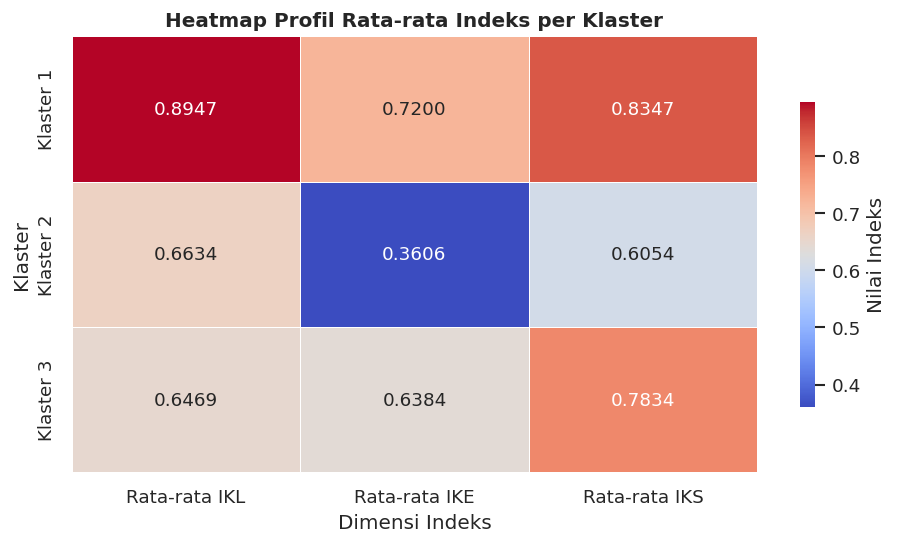

In [ ]:
# Profil rata-rata tiap klaster
profil = (
    df_cluster
    .groupby('KLASTER')[FITUR_3D]
    .agg(['mean', 'median', 'std'])
    .round(4)
)

# Tampilkan rata-rata saja untuk ringkasan
profil_mean = df_cluster.groupby('KLASTER')[FITUR_3D].mean().round(4)
profil_mean.columns = ['Rata-rata IKL', 'Rata-rata IKE', 'Rata-rata IKS']
profil_mean.index = [f'Klaster {i+1}' for i in profil_mean.index]
profil_mean['Jumlah Desa'] = dist_klaster.values
profil_mean['IDM Estimasi'] = (
    profil_mean[['Rata-rata IKL', 'Rata-rata IKE', 'Rata-rata IKS']].mean(axis=1).round(4)
)

print('Profil Rata-rata Tiap Klaster:')
display(profil_mean)

# Heatmap profil
fig, ax = plt.subplots(figsize=(8, K_OPTIMAL * 0.9 + 2))
sns.heatmap(
    profil_mean.drop(columns=['Jumlah Desa', 'IDM Estimasi']),
    annot=True, fmt='.4f', cmap='coolwarm',
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 11},
    cbar_kws={'label': 'Nilai Indeks', 'shrink': 0.7},
    ax=ax
)
ax.set_title('Heatmap Profil Rata-rata Indeks per Klaster', fontsize=12, fontweight='bold')
ax.set_xlabel('Dimensi Indeks')
ax.set_ylabel('Klaster')
plt.tight_layout()
plt.savefig('profil_klaster_heatmap.png', bbox_inches='tight')
plt.show()

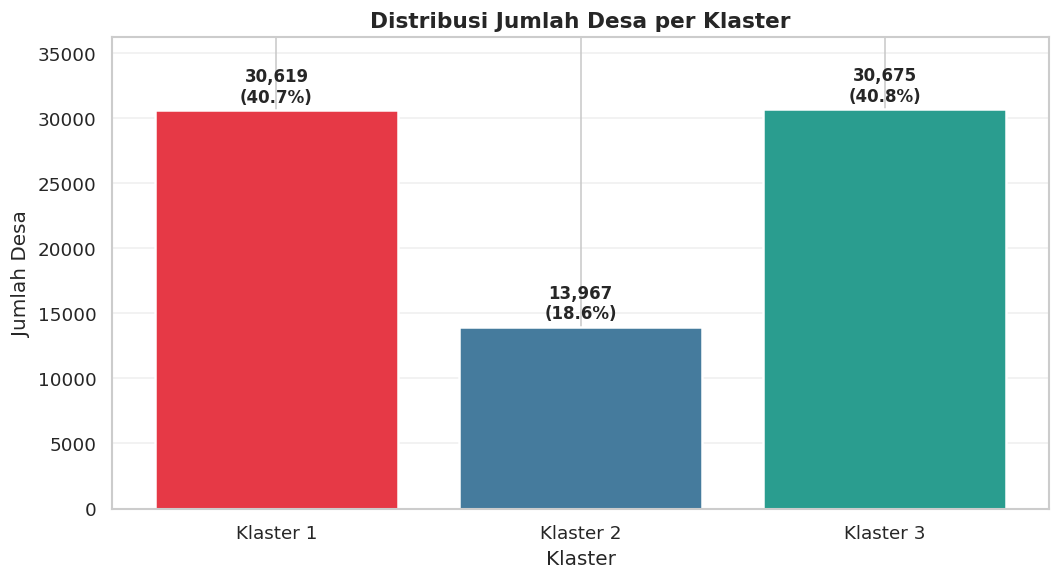

In [ ]:
# Bar chart distribusi klaster
klaster_counts = df_cluster['KLASTER'].value_counts().sort_index()
klaster_labels = [f'Klaster {k+1}' for k in klaster_counts.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(klaster_labels, klaster_counts.values,
              color=[PALET[k % len(PALET)] for k in klaster_counts.index],
              edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, klaster_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + klaster_counts.max() * 0.01,
            f'{val:,}\n({val/len(df_cluster)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xlabel('Klaster')
ax.set_ylabel('Jumlah Desa')
ax.set_title('Distribusi Jumlah Desa per Klaster', fontsize=13, fontweight='bold')
ax.set_ylim(0, klaster_counts.max() * 1.18)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('distribusi_klaster.png', bbox_inches='tight')
plt.show()

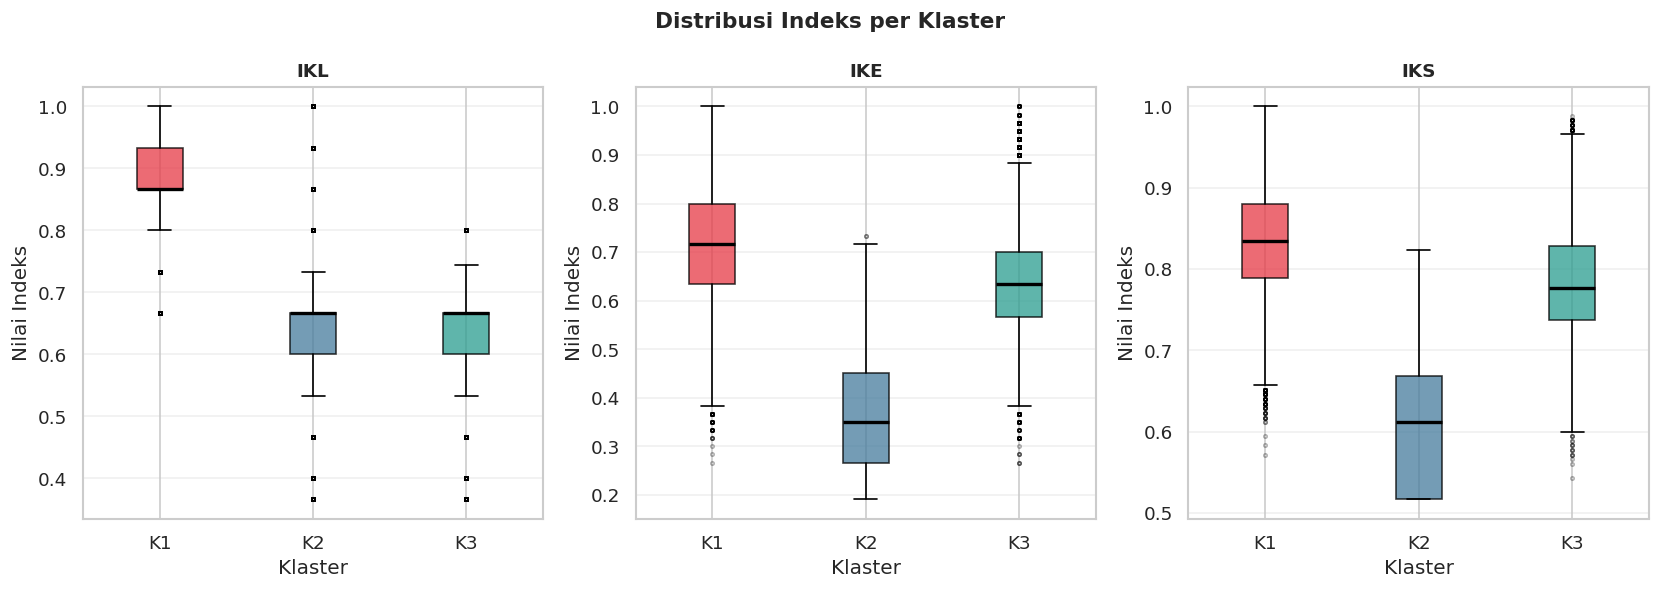

In [ ]:
# Box plot distribusi indeks per klaster
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(FITUR_3D):
    data_groups = [
        df_cluster[df_cluster['KLASTER'] == k][col].values
        for k in sorted(df_cluster['KLASTER'].unique())
    ]
    bp = axes[i].boxplot(
        data_groups, patch_artist=True,
        labels=[f'K{k+1}' for k in sorted(df_cluster['KLASTER'].unique())],
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='o', markersize=2, alpha=0.3)
    )
    for patch, color in zip(bp['boxes'],
                             [PALET[k % len(PALET)]
                              for k in sorted(df_cluster['KLASTER'].unique())]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    axes[i].set_title(col.replace('_2024', ''), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Klaster')
    axes[i].set_ylabel('Nilai Indeks')
    axes[i].grid(axis='y', alpha=0.3)

fig.suptitle('Distribusi Indeks per Klaster', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_per_klaster.png', bbox_inches='tight')
plt.show()

Nilai STATUS_IDM_2024 yang ditemukan: ['BERKEMBANG', 'MAJU', 'MANDIRI', 'SANGAT TERTINGGAL', 'TERTINGGAL']


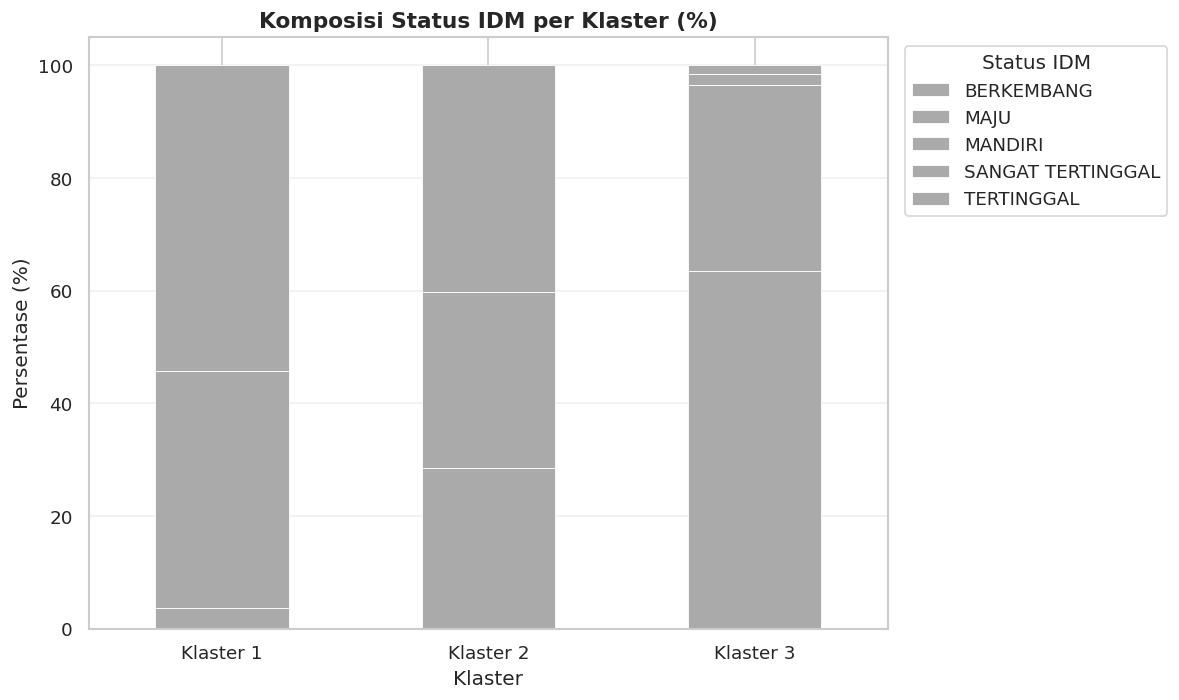


Komposisi Status IDM per Klaster (%):


STATUS_IDM_2024,BERKEMBANG,MAJU,MANDIRI,SANGAT TERTINGGAL,TERTINGGAL
Klaster 1,3.5900,42.1600,54.2500,0.0000,0.0000
Klaster 2,28.4700,0.0100,0.0000,31.2100,40.3200
Klaster 3,63.4300,33.1000,1.9300,0.0100,1.5300


In [ ]:
# Komposisi STATUS_IDM per klaster (stacked bar)
if 'STATUS_IDM_2024' in df_hasil.columns:

    df_hasil = df_hasil.copy()
    df_hasil['STATUS_IDM_2024'] = df_hasil['STATUS_IDM_2024'].astype(str).str.strip()

    status_klaster = (
        df_hasil
        .groupby(['KLASTER', 'STATUS_IDM_2024'])
        .size()
        .unstack(fill_value=0)
    )
    status_klaster.index = [f'Klaster {i+1}' for i in status_klaster.index]

    status_pct = status_klaster.div(status_klaster.sum(axis=1), axis=0) * 100

    URUTAN_BAKU = ['Sangat Tertinggal', 'Tertinggal', 'Berkembang', 'Maju', 'Mandiri']
    urutan = [s for s in URUTAN_BAKU if s in status_pct.columns]
    if not urutan:
        print('Nilai STATUS_IDM_2024 yang ditemukan:', list(status_pct.columns))
        urutan = list(status_pct.columns)
    status_pct = status_pct[urutan]

    if status_pct.empty or status_pct.shape[1] == 0:
        print('Tidak ada data komposisi status untuk divisualisasi.')
    else:
        COLOR_MAP = {
            'Sangat Tertinggal': '#d62728',
            'Tertinggal'       : '#ff7f0e',
            'Berkembang'       : '#2ca02c',
            'Maju'             : '#1f77b4',
            'Mandiri'          : '#9467bd',
        }
        plot_colors = [COLOR_MAP.get(s, '#aaaaaa') for s in urutan]

        fig, ax = plt.subplots(figsize=(10, 6))
        status_pct.plot(
            kind='bar', stacked=True, ax=ax,
            color=plot_colors,
            edgecolor='white', linewidth=0.5
        )
        ax.set_title('Komposisi Status IDM per Klaster (%)', fontsize=13, fontweight='bold')
        ax.set_xlabel('Klaster')
        ax.set_ylabel('Persentase (%)')
        ax.legend(title='Status IDM', bbox_to_anchor=(1.01, 1), loc='upper left')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.savefig('status_per_klaster.png', bbox_inches='tight')
        plt.show()

    print('\nKomposisi Status IDM per Klaster (%):')
    display(status_pct.round(2))

---
## 9. Simpan Hasil Preprocessing

| File | Isi |
|------|-----|
| `idm_2024_clean.csv` | Data bersih setelah cleaning + winsorization (tanpa label klaster) |
| `idm_2024_clustered.csv` | Data bersih + kolom `KLASTER` dan `KLASTER_LABEL` |
| `idm_2024_median_modus_per_provinsi.csv` | Tabel ekstraksi median & modus per provinsi |

File disimpan di direktori kerja Colab (`/content/`). Jalankan blok opsional di bawah  
untuk menyalin ke Google Drive.


In [ ]:
# Simpan data bersih
df_clean.to_csv('idm_2024_clean.csv', index=False, encoding='utf-8-sig')
print(f'[OK] idm_2024_clean.csv              - {len(df_clean):,} baris')

# Simpan data dengan klaster
df_hasil.to_csv('idm_2024_clustered.csv', index=False, encoding='utf-8-sig')
print(f'[OK] idm_2024_clustered.csv          - {len(df_hasil):,} baris')

# Simpan ekstraksi per provinsi
hasil_ekstraksi.to_csv('idm_2024_median_modus_per_provinsi.csv', index=False, encoding='utf-8-sig')
print(f'[OK] idm_2024_median_modus_per_provinsi.csv - {len(hasil_ekstraksi)} provinsi')

print()
print(' Preprocessing selesai! Semua file tersedia di direktori Colab (/content/).')
print()
print('--- Untuk menyalin ke Google Drive (opsional) ---')
print('import shutil')
print('shutil.copy("idm_2024_clean.csv", "/content/drive/MyDrive/DataAnalytics/idm_2024_clean.csv")')
print('shutil.copy("idm_2024_clustered.csv", "/content/drive/MyDrive/DataAnalytics/idm_2024_clustered.csv")')
print('shutil.copy("idm_2024_median_modus_per_provinsi.csv", "/content/drive/MyDrive/DataAnalytics/idm_2024_median_modus_per_provinsi.csv")')

[OK] idm_2024_clean.csv              - 75,265 baris
[OK] idm_2024_clustered.csv          - 75,261 baris
[OK] idm_2024_median_modus_per_provinsi.csv - 37 provinsi

 Preprocessing selesai! Semua file tersedia di direktori Colab (/content/).

--- Untuk menyalin ke Google Drive (opsional) ---
import shutil
shutil.copy("idm_2024_clean.csv", "/content/drive/MyDrive/DataAnalytics/idm_2024_clean.csv")
shutil.copy("idm_2024_clustered.csv", "/content/drive/MyDrive/DataAnalytics/idm_2024_clustered.csv")
shutil.copy("idm_2024_median_modus_per_provinsi.csv", "/content/drive/MyDrive/DataAnalytics/idm_2024_median_modus_per_provinsi.csv")


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# =========================================================
# 1. LOAD DATA
# =========================================================
df = pd.read_csv("idm_2024_clean.csv")

feature_cols = ["IKS_2024", "IKE_2024", "IKL_2024"]
X = df[feature_cols].copy()

# Simple preprocessing
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imp = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imp)

# Untuk efisiensi pada data besar
np.random.seed(42)
sample_size = min(15000, len(X_scaled))
sample_idx = np.random.choice(len(X_scaled), size=sample_size, replace=False)
X_sample = X_scaled[sample_idx]

# =========================================================
# 2. AUTO SEARCH CLUSTERING
# =========================================================
results = []

# KMeans
for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        max_iter=500,
        random_state=42
    )
    labels = model.fit_predict(X_sample)

    results.append({
        "algorithm": "KMeans",
        "params": {"n_clusters": k},
        "silhouette": silhouette_score(X_sample, labels),
        "calinski_harabasz": calinski_harabasz_score(X_sample, labels),
        "davies_bouldin": davies_bouldin_score(X_sample, labels)
    })

# Agglomerative
for k in range(2, 11):
    for linkage in ["ward", "complete", "average", "single"]:
        if linkage == "ward":
            model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        else:
            model = AgglomerativeClustering(n_clusters=k, linkage=linkage, metric="euclidean")

        labels = model.fit_predict(X_sample)

        # single linkage kadang menghasilkan cluster buruk; tetap dinilai
        if len(np.unique(labels)) > 1:
            results.append({
                "algorithm": "Agglomerative",
                "params": {"n_clusters": k, "linkage": linkage},
                "silhouette": silhouette_score(X_sample, labels),
                "calinski_harabasz": calinski_harabasz_score(X_sample, labels),
                "davies_bouldin": davies_bouldin_score(X_sample, labels)
            })

# Gaussian Mixture
for k in range(2, 11):
    for cov in ["full", "tied", "diag", "spherical"]:
        model = GaussianMixture(
            n_components=k,
            covariance_type=cov,
            random_state=42
        )
        labels = model.fit_predict(X_sample)

        if len(np.unique(labels)) > 1:
            results.append({
                "algorithm": "GaussianMixture",
                "params": {"n_components": k, "covariance_type": cov},
                "silhouette": silhouette_score(X_sample, labels),
                "calinski_harabasz": calinski_harabasz_score(X_sample, labels),
                "davies_bouldin": davies_bouldin_score(X_sample, labels)
            })

results_df = pd.DataFrame(results)

# Ranking:
# silhouette tinggi lebih baik
# calinski tinggi lebih baik
# davies rendah lebih baik
results_df["rank_sil"] = results_df["silhouette"].rank(ascending=False, method="min")
results_df["rank_ch"] = results_df["calinski_harabasz"].rank(ascending=False, method="min")
results_df["rank_db"] = results_df["davies_bouldin"].rank(ascending=True, method="min")
results_df["rank_total"] = results_df["rank_sil"] + results_df["rank_ch"] + results_df["rank_db"]

results_df = results_df.sort_values("rank_total").reset_index(drop=True)

print("TOP 10 KONFIGURASI CLUSTERING")
print(results_df.head(10)[[
    "algorithm", "params", "silhouette", "calinski_harabasz", "davies_bouldin", "rank_total"
]])

best_row = results_df.iloc[0]
print("\nBEST CLUSTERING CONFIGURATION")
print(best_row)

results_df.to_csv("clustering_model_comparison.csv", index=False)
print("\n[OK] Hasil clustering comparison tersimpan di clustering_model_comparison.csv")

TOP 10 KONFIGURASI CLUSTERING
         algorithm                                             params  \
0           KMeans                                  {'n_clusters': 4}   
1  GaussianMixture     {'n_components': 3, 'covariance_type': 'diag'}   
2  GaussianMixture  {'n_components': 3, 'covariance_type': 'spheri...   
3  GaussianMixture  {'n_components': 4, 'covariance_type': 'spheri...   
4           KMeans                                  {'n_clusters': 3}   
5  GaussianMixture     {'n_components': 4, 'covariance_type': 'diag'}   
6           KMeans                                  {'n_clusters': 5}   
7  GaussianMixture     {'n_components': 4, 'covariance_type': 'tied'}   
8    Agglomerative            {'n_clusters': 2, 'linkage': 'average'}   
9  GaussianMixture     {'n_components': 2, 'covariance_type': 'tied'}   

   silhouette  calinski_harabasz  davies_bouldin  rank_total  
0      0.3620         11479.0204          0.9314     30.0000  
1      0.3734         11274.8541        

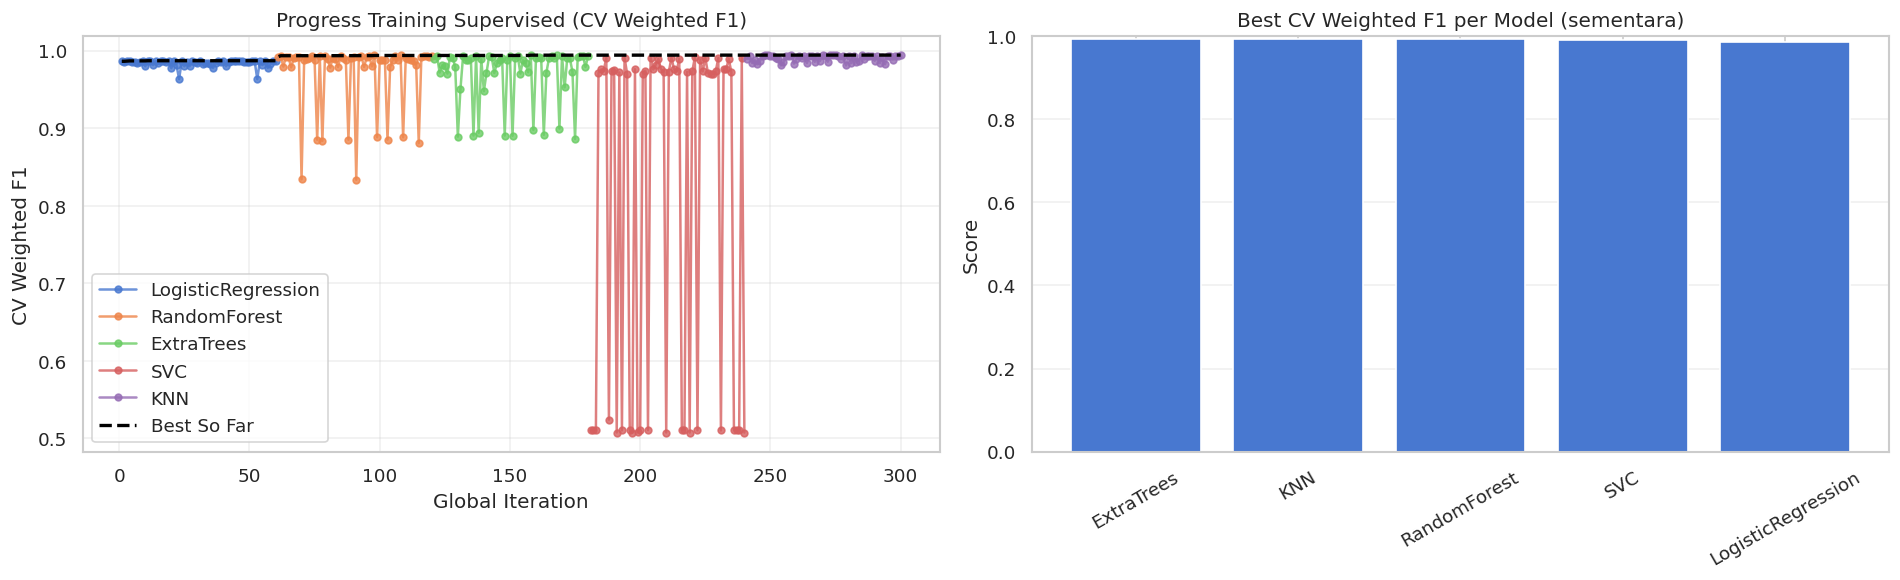

Progress: 300/300
Model saat ini : KNN
Rerun         : 3/3
Iterasi       : 20/20
Score iterasi : 0.99367
Best lokal    : 0.99382
Best global   : 0.99414
Best model    : ExtraTrees
Best params   : {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 30}

FINAL RESULT - SUPERVISED
Best model : ExtraTrees
Best params: {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 30}
Test Accuracy            : 0.99495
Test Weighted Precision  : 0.99496
Test Weighted Recall     : 0.99495
Test Weighted F1         : 0.99495

Classification Report:
                   precision    recall  f1-score   support

       BERKEMBANG       1.00      1.00      1.00      4907
             MAJU       1.00      1.00      1.00      4613
          MANDIRI       1.00      1.00      1.00      3441
SANGAT TERTINGGAL       0.97      0.99      0.98 

In [ ]:
# ==============================
# CELL SUPERVISED
# Real-time training progress
# ==============================

import warnings
warnings.filterwarnings("ignore")

import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import clear_output, display

from sklearn.model_selection import train_test_split, StratifiedKFold, ParameterSampler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import clone

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# ======================================================
# 1. LOAD DATA
# ======================================================
df = pd.read_csv("idm_2024_clean.csv")

feature_cols = ["IKS_2024", "IKE_2024", "IKL_2024"]
target_col = "STATUS_IDM_2024"

required_cols = feature_cols + [target_col]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Kolom wajib tidak ditemukan: {missing_cols}")

df_model = df[required_cols].copy()
df_model = df_model.dropna(subset=[target_col]).reset_index(drop=True)

X = df_model[feature_cols]
y_raw = df_model[target_col].astype(str).str.strip()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

print("Distribusi kelas:")
print(pd.Series(y_raw).value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ======================================================
# 2. PREPROCESSOR
# ======================================================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, feature_cols)
    ]
)

# ======================================================
# 3. MODEL + SEARCH SPACE
# ======================================================
models = {
    "LogisticRegression": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
        ]),
        "params": {
            "model__C": np.linspace(0.05, 10, 30),
            "model__solver": ["lbfgs", "saga"]
        }
    },

    "RandomForest": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", RandomForestClassifier(
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            ))
        ]),
        "params": {
            "model__n_estimators": [100, 150, 200, 300, 400],
            "model__max_depth": [None, 5, 10, 15, 20, 30],
            "model__min_samples_split": [2, 5, 10, 15],
            "model__min_samples_leaf": [1, 2, 4, 6],
            "model__max_features": ["sqrt", "log2", None]
        }
    },

    "ExtraTrees": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", ExtraTreesClassifier(
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            ))
        ]),
        "params": {
            "model__n_estimators": [100, 150, 200, 300, 400],
            "model__max_depth": [None, 5, 10, 15, 20, 30],
            "model__min_samples_split": [2, 5, 10, 15],
            "model__min_samples_leaf": [1, 2, 4, 6],
            "model__max_features": ["sqrt", "log2", None]
        }
    },

    "SVC": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", SVC(class_weight="balanced"))
        ]),
        "params": {
            "model__C": np.linspace(0.1, 15, 30),
            "model__kernel": ["rbf", "poly", "sigmoid"],
            "model__gamma": ["scale", "auto"]
        }
    },

    "KNN": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", KNeighborsClassifier())
        ]),
        "params": {
            "model__n_neighbors": list(range(3, 31, 2)),
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2]
        }
    }
}

# ======================================================
# 4. SETTINGS
# ======================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
N_ITER_PER_MODEL = 20
N_RERUNS = 3

# ======================================================
# 5. REAL-TIME TRAINING LOOP
# ======================================================
history = []
best_global_score = -np.inf
best_global_model = None
best_global_params = None
best_global_estimator = None

global_iter = 0
total_iters = len(models) * N_RERUNS * N_ITER_PER_MODEL

for model_name, config in models.items():
    for rerun in range(1, N_RERUNS + 1):
        sampler = list(ParameterSampler(
            param_distributions=config["params"],
            n_iter=N_ITER_PER_MODEL,
            random_state=42 + rerun
        ))

        best_local_score = -np.inf
        best_local_params = None

        for i, params in enumerate(sampler, start=1):
            global_iter += 1

            pipe = clone(config["pipeline"])
            pipe.set_params(**params)

            scores = cross_val_score(
                pipe,
                X_train,
                y_train,
                cv=cv,
                scoring="f1_weighted",
                n_jobs=-1
            )
            mean_score = scores.mean()

            history.append({
                "global_iter": global_iter,
                "model": model_name,
                "rerun": rerun,
                "iter_in_rerun": i,
                "cv_f1_weighted": mean_score,
                "best_so_far_before_update": best_global_score
            })

            if mean_score > best_local_score:
                best_local_score = mean_score
                best_local_params = params

            if mean_score > best_global_score:
                best_global_score = mean_score
                best_global_model = model_name
                best_global_params = params
                best_global_estimator = clone(config["pipeline"]).set_params(**params)
                best_global_estimator.fit(X_train, y_train)

            # ------------------------------
            # REAL-TIME VISUALIZATION
            # ------------------------------
            hist_df = pd.DataFrame(history)

            clear_output(wait=True)
            fig, axes = plt.subplots(1, 2, figsize=(16, 5))

            # Plot 1: skor semua iterasi
            for m in hist_df["model"].unique():
                temp = hist_df[hist_df["model"] == m]
                axes[0].plot(
                    temp["global_iter"],
                    temp["cv_f1_weighted"],
                    marker="o",
                    linewidth=1.5,
                    markersize=4,
                    label=m,
                    alpha=0.8
                )

            best_line = hist_df["cv_f1_weighted"].cummax()
            axes[0].plot(
                hist_df["global_iter"],
                best_line,
                linestyle="--",
                linewidth=2,
                color="black",
                label="Best So Far"
            )
            axes[0].set_title("Progress Training Supervised (CV Weighted F1)")
            axes[0].set_xlabel("Global Iteration")
            axes[0].set_ylabel("CV Weighted F1")
            axes[0].grid(True, alpha=0.3)
            axes[0].legend()

            # Plot 2: best score per model sementara
            best_per_model = hist_df.groupby("model")["cv_f1_weighted"].max().sort_values(ascending=False)
            axes[1].bar(best_per_model.index, best_per_model.values)
            axes[1].set_title("Best CV Weighted F1 per Model (sementara)")
            axes[1].set_ylabel("Score")
            axes[1].set_ylim(0, min(1.0, max(0.1, best_per_model.max() + 0.05)))
            axes[1].tick_params(axis="x", rotation=30)
            axes[1].grid(True, axis="y", alpha=0.3)

            plt.tight_layout()
            display(fig)
            plt.close(fig)

            print(f"Progress: {global_iter}/{total_iters}")
            print(f"Model saat ini : {model_name}")
            print(f"Rerun         : {rerun}/{N_RERUNS}")
            print(f"Iterasi       : {i}/{N_ITER_PER_MODEL}")
            print(f"Score iterasi : {mean_score:.5f}")
            print(f"Best lokal    : {best_local_score:.5f}")
            print(f"Best global   : {best_global_score:.5f}")
            print(f"Best model    : {best_global_model}")
            print(f"Best params   : {best_global_params}")

# ======================================================
# 6. FINAL EVALUATION
# ======================================================
y_pred = best_global_estimator.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1w = f1_score(y_test, y_pred, average="weighted")
prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)

print("\n" + "="*70)
print("FINAL RESULT - SUPERVISED")
print("="*70)
print("Best model :", best_global_model)
print("Best params:", best_global_params)
print(f"Test Accuracy            : {acc:.5f}")
print(f"Test Weighted Precision  : {prec:.5f}")
print(f"Test Weighted Recall     : {rec:.5f}")
print(f"Test Weighted F1         : {f1w:.5f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in label_encoder.classes_],
    columns=[f"Pred_{c}" for c in label_encoder.classes_]
)
print("\nConfusion Matrix:")
print(cm_df)

# Simpan hasil
pd.DataFrame(history).to_csv("supervised_training_progress.csv", index=False)
pd.DataFrame([{
    "best_model": best_global_model,
    "best_params": str(best_global_params),
    "test_accuracy": acc,
    "test_precision_weighted": prec,
    "test_recall_weighted": rec,
    "test_f1_weighted": f1w
}]).to_csv("supervised_best_result.csv", index=False)

print("\nFile tersimpan:")
print("- supervised_training_progress.csv")
print("- supervised_best_result.csv")

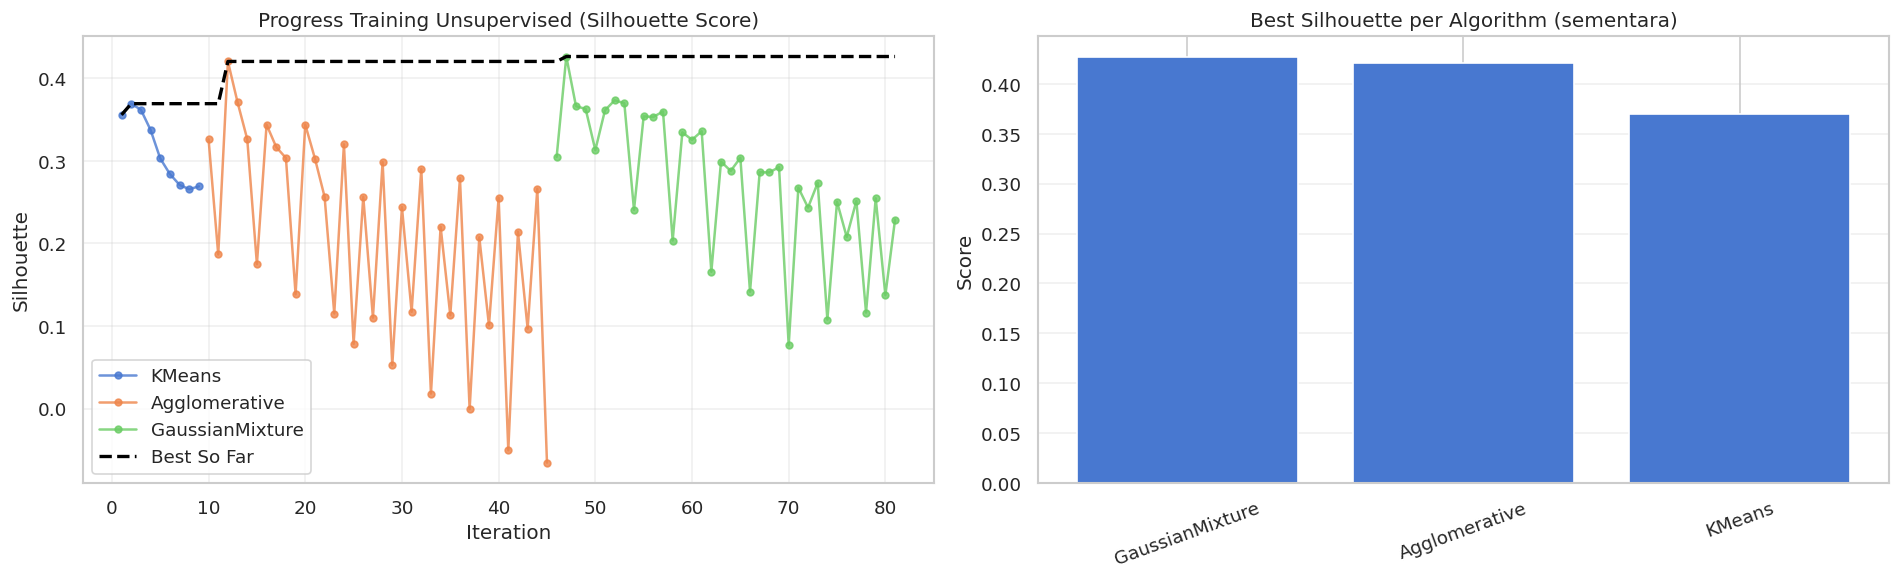

Progress: 81/81
Algorithm saat ini : GaussianMixture
Parameter          : {'n_components': 10, 'covariance_type': 'spherical'}
Silhouette         : 0.22896
Calinski-Harabasz  : 7204.96463
Davies-Bouldin     : 1.09836

Best sementara:
{'algorithm': 'GaussianMixture', 'params': {'n_components': 2, 'covariance_type': 'tied'}, 'silhouette': np.float64(0.42646452363352777), 'calinski_harabasz': np.float64(7940.729811227035), 'davies_bouldin': np.float64(0.7880804177933804)}

FINAL RESULT - UNSUPERVISED
Top 10 konfigurasi clustering:
         algorithm                                             params  \
0  GaussianMixture     {'n_components': 3, 'covariance_type': 'diag'}   
1           KMeans                                  {'n_clusters': 4}   
2  GaussianMixture  {'n_components': 3, 'covariance_type': 'spheri...   
3  GaussianMixture  {'n_components': 4, 'covariance_type': 'spheri...   
4           KMeans                                  {'n_clusters': 3}   
5  GaussianMixture     {'n_c

In [ ]:
# ==============================
# CELL UNSUPERVISED
# Real-time training progress
# ==============================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import clear_output, display
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# ======================================================
# 1. LOAD DATA
# ======================================================
df = pd.read_csv("idm_2024_clean.csv")
feature_cols = ["IKS_2024", "IKE_2024", "IKL_2024"]

missing_cols = [c for c in feature_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Kolom fitur tidak ditemukan: {missing_cols}")

X = df[feature_cols].copy()

# Preprocessing ringan untuk clustering
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imp = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imp)

# Sampel jika data sangat besar agar visualisasi lebih ringan
np.random.seed(42)
sample_size = min(15000, len(X_scaled))
sample_idx = np.random.choice(len(X_scaled), size=sample_size, replace=False)
X_sample = X_scaled[sample_idx]

print("Jumlah data clustering:", len(X_sample))

# ======================================================
# 2. BUILD CONFIGURATION LIST
# ======================================================
configs = []

# KMeans
for k in range(2, 11):
    configs.append({
        "algorithm": "KMeans",
        "params": {"n_clusters": k}
    })

# Agglomerative
for k in range(2, 11):
    for linkage in ["ward", "complete", "average", "single"]:
        configs.append({
            "algorithm": "Agglomerative",
            "params": {"n_clusters": k, "linkage": linkage}
        })

# GaussianMixture
for k in range(2, 11):
    for cov in ["full", "tied", "diag", "spherical"]:
        configs.append({
            "algorithm": "GaussianMixture",
            "params": {"n_components": k, "covariance_type": cov}
        })

# ======================================================
# 3. REAL-TIME SEARCH LOOP
# ======================================================
results = []
best_silhouette = -np.inf
best_config = None
total_iters = len(configs)

for idx, cfg in enumerate(configs, start=1):
    algorithm = cfg["algorithm"]
    params = cfg["params"]

    # ----------------------------------------
    # Train clustering model
    # ----------------------------------------
    if algorithm == "KMeans":
        model = KMeans(
            n_clusters=params["n_clusters"],
            init="k-means++",
            n_init=20,
            max_iter=500,
            random_state=42
        )
        labels = model.fit_predict(X_sample)

    elif algorithm == "Agglomerative":
        if params["linkage"] == "ward":
            model = AgglomerativeClustering(
                n_clusters=params["n_clusters"],
                linkage=params["linkage"]
            )
        else:
            model = AgglomerativeClustering(
                n_clusters=params["n_clusters"],
                linkage=params["linkage"],
                metric="euclidean"
            )
        labels = model.fit_predict(X_sample)

    elif algorithm == "GaussianMixture":
        model = GaussianMixture(
            n_components=params["n_components"],
            covariance_type=params["covariance_type"],
            random_state=42
        )
        labels = model.fit_predict(X_sample)

    unique_clusters = np.unique(labels)

    # Jika hanya 1 cluster, skip evaluasi
    if len(unique_clusters) < 2:
        continue

    sil = silhouette_score(X_sample, labels)
    ch = calinski_harabasz_score(X_sample, labels)
    db = davies_bouldin_score(X_sample, labels)

    results.append({
        "iter": idx,
        "algorithm": algorithm,
        "params": str(params),
        "silhouette": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db
    })

    if sil > best_silhouette:
        best_silhouette = sil
        best_config = {
            "algorithm": algorithm,
            "params": params,
            "silhouette": sil,
            "calinski_harabasz": ch,
            "davies_bouldin": db
        }

    # ----------------------------------------
    # REAL-TIME VISUALIZATION
    # ----------------------------------------
    res_df = pd.DataFrame(results)

    clear_output(wait=True)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Plot 1: silhouette per iterasi
    for alg in res_df["algorithm"].unique():
        temp = res_df[res_df["algorithm"] == alg]
        axes[0].plot(
            temp["iter"],
            temp["silhouette"],
            marker="o",
            linewidth=1.5,
            markersize=4,
            label=alg,
            alpha=0.8
        )

    axes[0].plot(
        res_df["iter"],
        res_df["silhouette"].cummax(),
        linestyle="--",
        color="black",
        linewidth=2,
        label="Best So Far"
    )
    axes[0].set_title("Progress Training Unsupervised (Silhouette Score)")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Silhouette")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # Plot 2: best silhouette per algorithm
    best_per_alg = res_df.groupby("algorithm")["silhouette"].max().sort_values(ascending=False)
    axes[1].bar(best_per_alg.index, best_per_alg.values)
    axes[1].set_title("Best Silhouette per Algorithm (sementara)")
    axes[1].set_ylabel("Score")
    axes[1].tick_params(axis="x", rotation=20)
    axes[1].grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    display(fig)
    plt.close(fig)

    print(f"Progress: {idx}/{total_iters}")
    print(f"Algorithm saat ini : {algorithm}")
    print(f"Parameter          : {params}")
    print(f"Silhouette         : {sil:.5f}")
    print(f"Calinski-Harabasz  : {ch:.5f}")
    print(f"Davies-Bouldin     : {db:.5f}")
    print("\nBest sementara:")
    print(best_config)

# ======================================================
# 4. FINAL RANKING
# ======================================================
results_df = pd.DataFrame(results)

results_df["rank_sil"] = results_df["silhouette"].rank(ascending=False, method="min")
results_df["rank_ch"] = results_df["calinski_harabasz"].rank(ascending=False, method="min")
results_df["rank_db"] = results_df["davies_bouldin"].rank(ascending=True, method="min")
results_df["rank_total"] = results_df["rank_sil"] + results_df["rank_ch"] + results_df["rank_db"]

results_df = results_df.sort_values(["rank_total", "silhouette"], ascending=[True, False]).reset_index(drop=True)

print("\n" + "="*70)
print("FINAL RESULT - UNSUPERVISED")
print("="*70)
print("Top 10 konfigurasi clustering:")
print(results_df.head(10)[[
    "algorithm",
    "params",
    "silhouette",
    "calinski_harabasz",
    "davies_bouldin",
    "rank_total"
]])

print("\nBest berdasarkan ranking gabungan:")
print(results_df.iloc[0])

results_df.to_csv("unsupervised_training_progress.csv", index=False)
print("\nFile tersimpan:")
print("- unsupervised_training_progress.csv")